# SSF AI Toolkit - Visualization Test Notebook

This notebook tests all visualization functions with synthetic data.
Run all cells to verify everything works before using your real data.

**What this notebook does:**
1. ✅ Generates synthetic fishing vessel tracks
2. ✅ Trains an effort classifier
3. ✅ Makes predictions (fishing vs. non-fishing)
4. ✅ Creates all visualizations (tracks, heatmaps, hotspots)
5. ✅ Displays results inline

**Requirements:**
```bash
pip install -e .[viz]  # Or: pip install -e .
```

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display, HTML
import warnings
warnings.filterwarnings('ignore')

# For inline plotting
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


---
## Step 1: Generate Synthetic Tracking Data

We'll create realistic fishing vessel tracks with:
- Departure from port
- Transit to fishing ground
- Fishing activity (meandering pattern)
- Return to port

In [2]:
# Statistical effort classifier
from ssfaitk.models.effort.statistical_effort import (
    StatisticalEffortClassifier,
    predict_fishing_effort,
)

# data_path = "../../data/dfKenyaAll_Tracks_df_cleaned.csv"
# df = pd.read_csv(data_path)
# Load your data
df = pd.read_parquet('../../data/kenya-pds-tracks_14119254.parquet')

# Check columns
print(df.columns.tolist())
print(df.head())


clf = StatisticalEffortClassifier()

# One-line prediction with default settings
predictions_simple = clf.predict(
    df)

"""trip_col='Trip_ID',
lat_col='Latitude',
lon_col='Longitude',
time_col='ltime'"""


['Time', 'Boat', 'Trip', 'Lat', 'Lng', 'Speed (M/S)', 'Range (Meters)', 'Heading', 'Boat Name', 'Community']
                       Time     Boat        Trip      Lat       Lng  \
0 2025-10-26 13:04:26+00:00  25173.0  14119254.0 -2.54604  40.53776   
1 2025-10-26 13:04:38+00:00  25173.0  14119254.0 -2.54630  40.53813   
2 2025-10-26 13:04:50+00:00  25173.0  14119254.0 -2.54649  40.53840   
3 2025-10-26 13:05:08+00:00  25173.0  14119254.0 -2.54709  40.53920   
4 2025-10-26 13:05:09+00:00  25173.0  14119254.0 -2.54712  40.53928   

   Speed (M/S)  Range (Meters)  Heading      Boat Name  \
0         0.00        0.000000    122.0  Najua mtasema   
1         4.18       50.196601    134.0  Najua mtasema   
2         3.05       86.843670    146.0  Najua mtasema   
3         6.16      197.803340    126.0  Najua mtasema   
4         9.49      206.968969    123.0  Najua mtasema   

                                           Community  
0  Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...  
1  Ki

"trip_col='Trip_ID',\nlat_col='Latitude',\nlon_col='Longitude',\ntime_col='ltime'"

In [4]:
predictions_simple.head(10)

,timestamp,Boat,trip_id,latitude,longitude,Speed (M/S),Range (Meters),Heading,Boat Name,Community,...,trip_position,is_fishing_speed,is_transit_speed,is_high_turning,is_low_straightness,is_high_sinuosity,is_clustered,is_variable_speed,fishing_score,is_fishing
0,2025-10-26 13:04:26+00:00,25173.0,14119254.0,-2.54604,40.53776,0.00,0.000000,122.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000000,0,1,0,0,0,1,0,0.0,0
1,2025-10-26 13:04:38+00:00,25173.0,14119254.0,-2.54630,40.53813,4.18,50.196601,134.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000199,0,1,0,0,0,1,0,0.0,0
2,2025-10-26 13:04:50+00:00,25173.0,14119254.0,-2.54649,40.53840,3.05,86.843670,146.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000398,0,1,0,0,0,1,0,0.0,0
3,2025-10-26 13:05:08+00:00,25173.0,14119254.0,-2.54709,40.53920,6.16,197.803340,126.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000596,0,1,0,0,0,1,0,0.0,0
4,2025-10-26 13:05:09+00:00,25173.0,14119254.0,-2.54712,40.53928,9.49,206.968969,123.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000795,0,1,0,0,0,1,0,0.0,0
5,2025-10-26 13:05:10+00:00,25173.0,14119254.0,-2.54712,40.53931,3.33,209.702699,115.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.000994,0,1,0,0,0,1,0,0.0,0
6,2025-10-26 13:05:11+00:00,25173.0,14119254.0,-2.54712,40.53935,4.44,213.374339,122.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.001193,0,1,0,0,0,1,0,0.0,0
7,2025-10-26 13:05:12+00:00,25173.0,14119254.0,-2.54716,40.53935,4.42,215.880979,124.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.001391,0,1,0,0,0,1,0,0.0,0
8,2025-10-26 13:05:13+00:00,25173.0,14119254.0,-2.54719,40.53940,6.47,222.339051,130.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.001590,0,1,0,0,0,1,0,0.0,0
9,2025-10-26 13:05:14+00:00,25173.0,14119254.0,-2.54722,40.53943,4.70,226.974550,130.0,Najua mtasema,"Kipini,2025-10-26 14:09:58+00,2025-11-06 00:48...",...,0.001789,0,1,0,0,0,1,0,0.0,0


---
## Step 4: Create Visualizations

Test all visualization functions.

In [6]:
# Import visualization functions
from ssfaitk.viz import (
    plot_effort_tracks,
    plot_effort_heatmap,
    plot_effort_hotspots,
    plot_effort_comparison,
)

# Create output directory
output_dir = Path('test_outputs')
output_dir.mkdir(exist_ok=True)

print("✓ Visualization functions imported")
print(f"  Output directory: {output_dir}/")

✓ Visualization functions imported
  Output directory: test_outputs/


### 4.1 Track Plot (Colored Routes)

### 4.2 Heatmap (Spatial Density)

### 4.3 Hotspot Analysis

### 4.4 Comparison Plot (Side-by-Side)

---
## Step 5: Generate Complete Report

Create all visualizations at once.

In [11]:
from ssfaitk.viz import generate_effort_report

print("Generating complete report...")
print()

outputs = generate_effort_report(
    predictions_simple,
    output_dir=output_dir / 'report',
    grid_size=0.01,
    prefix='test_effort'
)

print()
print("✓ Complete report generated!")
print(f"\n📁 Files created:")
for plot_type, path in outputs.items():
    print(f"  • {plot_type}: {path}")

[INFO] 2025-12-04 13:33:10,048 ssfaitk.viz.effort_maps: Resolved columns: effort=is_fishing, lat=latitude, lon=longitude, trip=trip_id
[INFO] 2025-12-04 13:33:10,049 ssfaitk.viz.effort_maps: Generating effort analysis report...
[INFO] 2025-12-04 13:33:10,050 ssfaitk.viz.effort_maps: Creating track plot...


Generating complete report...



[INFO] 2025-12-04 13:33:10,296 ssfaitk.viz.base: Saved visualization: test_outputs/report/test_effort_tracks.png
[INFO] 2025-12-04 13:33:10,296 ssfaitk.viz.effort_maps: Creating heatmap...
[INFO] 2025-12-04 13:33:10,867 ssfaitk.viz.base: Saved visualization: test_outputs/report/test_effort_heatmap.png
[INFO] 2025-12-04 13:33:10,868 ssfaitk.viz.effort_maps: Creating hotspot analysis...
[INFO] 2025-12-04 13:33:11,808 ssfaitk.viz.base: Saved visualization: test_outputs/report/test_effort_hotspots.png
[INFO] 2025-12-04 13:33:11,809 ssfaitk.viz.effort_maps: Creating comparison plot...
[INFO] 2025-12-04 13:33:12,197 ssfaitk.viz.base: Saved visualization: test_outputs/report/test_effort_comparison.png
[INFO] 2025-12-04 13:33:12,197 ssfaitk.viz.effort_maps: Report complete! Files saved to: test_outputs/report



✓ Complete report generated!

📁 Files created:
  • tracks: test_outputs/report/test_effort_tracks.png
  • heatmap: test_outputs/report/test_effort_heatmap.png
  • hotspots: test_outputs/report/test_effort_hotspots.png
  • comparison: test_outputs/report/test_effort_comparison.png


---
## Step 6: Interactive Maps (Optional)

Create HTML maps if folium is installed.

In [12]:
try:
    from ssfaitk.viz.interactive_maps import (
        create_interactive_effort_map,
        create_heatmap_html
    )
    
    print("Creating interactive maps...")
    
    # Interactive track map
    path1 = create_interactive_effort_map(
        predictions_simple,
        output_path=output_dir / 'interactive_map.html',
        zoom_start=11
    )
    print(f"✓ Interactive track map: {path1}")
    
    # Interactive heatmap
    path2 = create_heatmap_html(
        predictions_simple,
        output_path=output_dir / 'interactive_heatmap.html',
        radius=15,
        blur=25
    )
    print(f"✓ Interactive heatmap: {path2}")
    
    print(f"\n💡 Open these HTML files in your browser to view interactive maps")
    
except ImportError:
    print("⚠ folium not installed (optional)")
    print("  Install with: pip install folium")
except Exception as e:
    print(f"⚠ Error creating interactive maps: {e}")

[INFO] 2025-12-04 13:33:14,661 ssfaitk.viz.interactive_maps: Saved interactive map: test_outputs/interactive_map.html
[INFO] 2025-12-04 13:33:14,673 ssfaitk.viz.interactive_maps: Saved interactive heatmap: test_outputs/interactive_heatmap.html


Creating interactive maps...
✓ Interactive track map: test_outputs/interactive_map.html
✓ Interactive heatmap: test_outputs/interactive_heatmap.html

💡 Open these HTML files in your browser to view interactive maps


---
## Step 7: Display Saved Images

View all generated static images.

📸 Displaying 8 saved images:


📄 report/test_effort_comparison.png


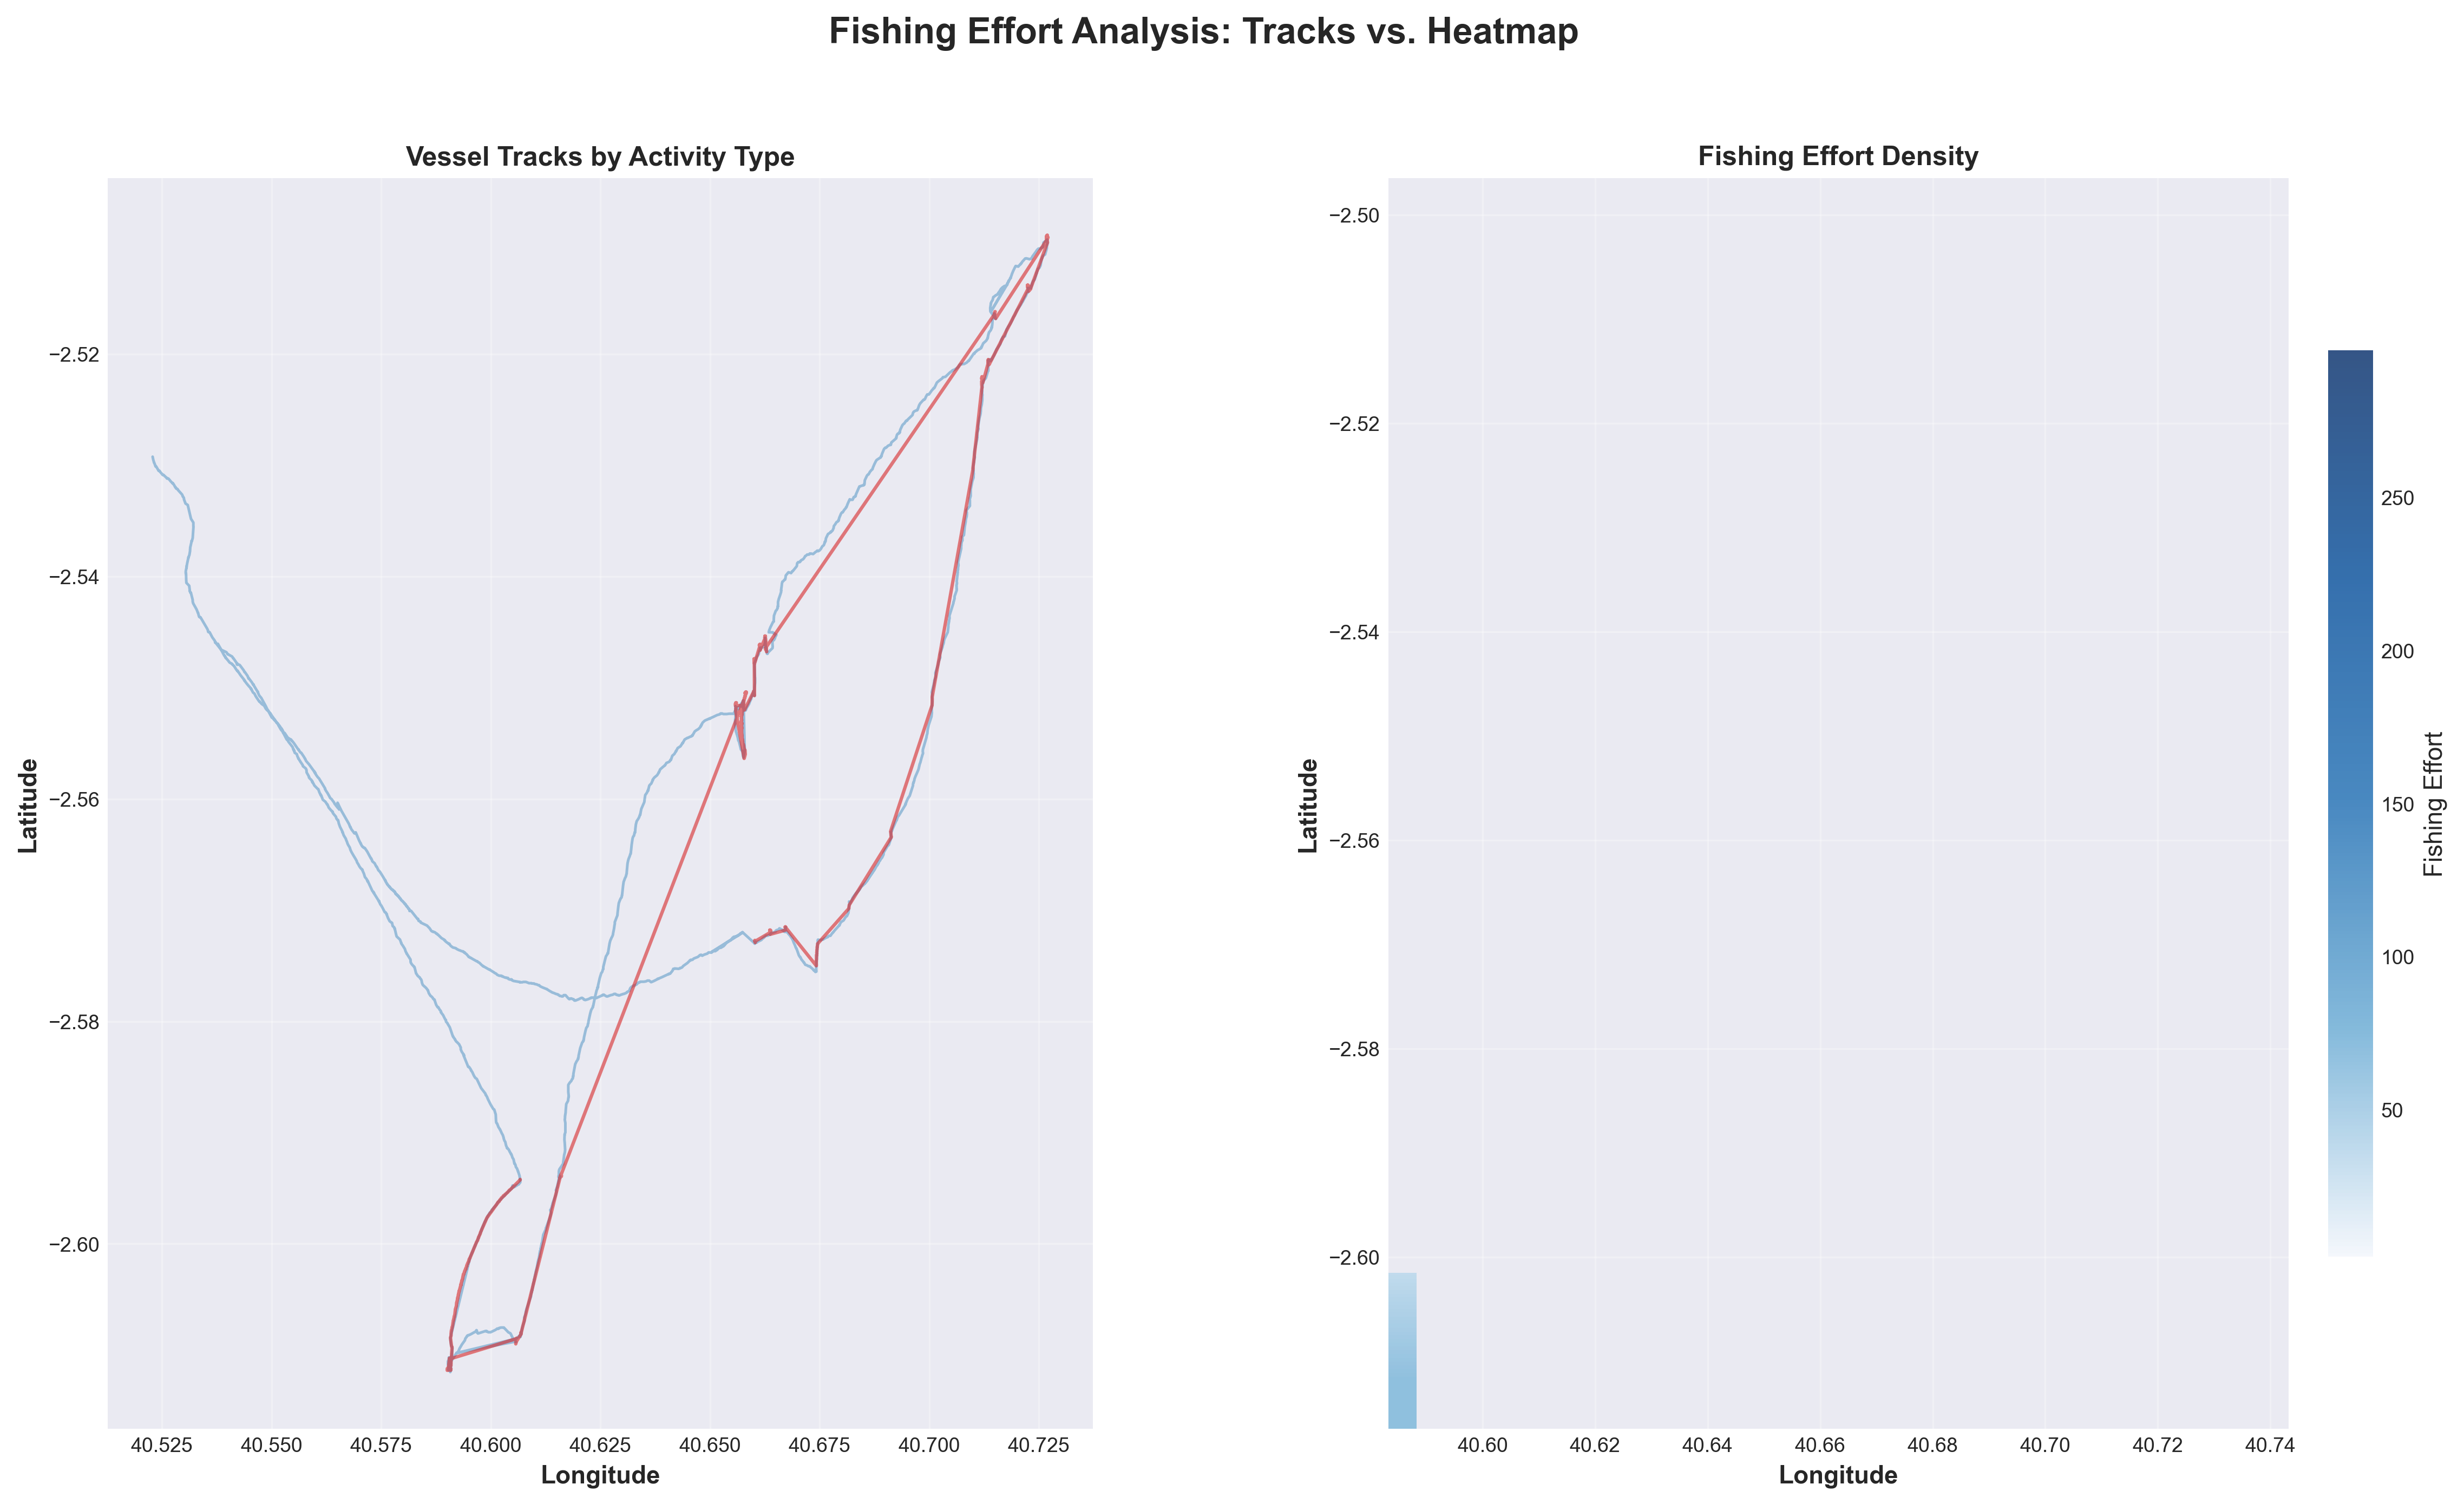


📄 report/test_effort_heatmap.png


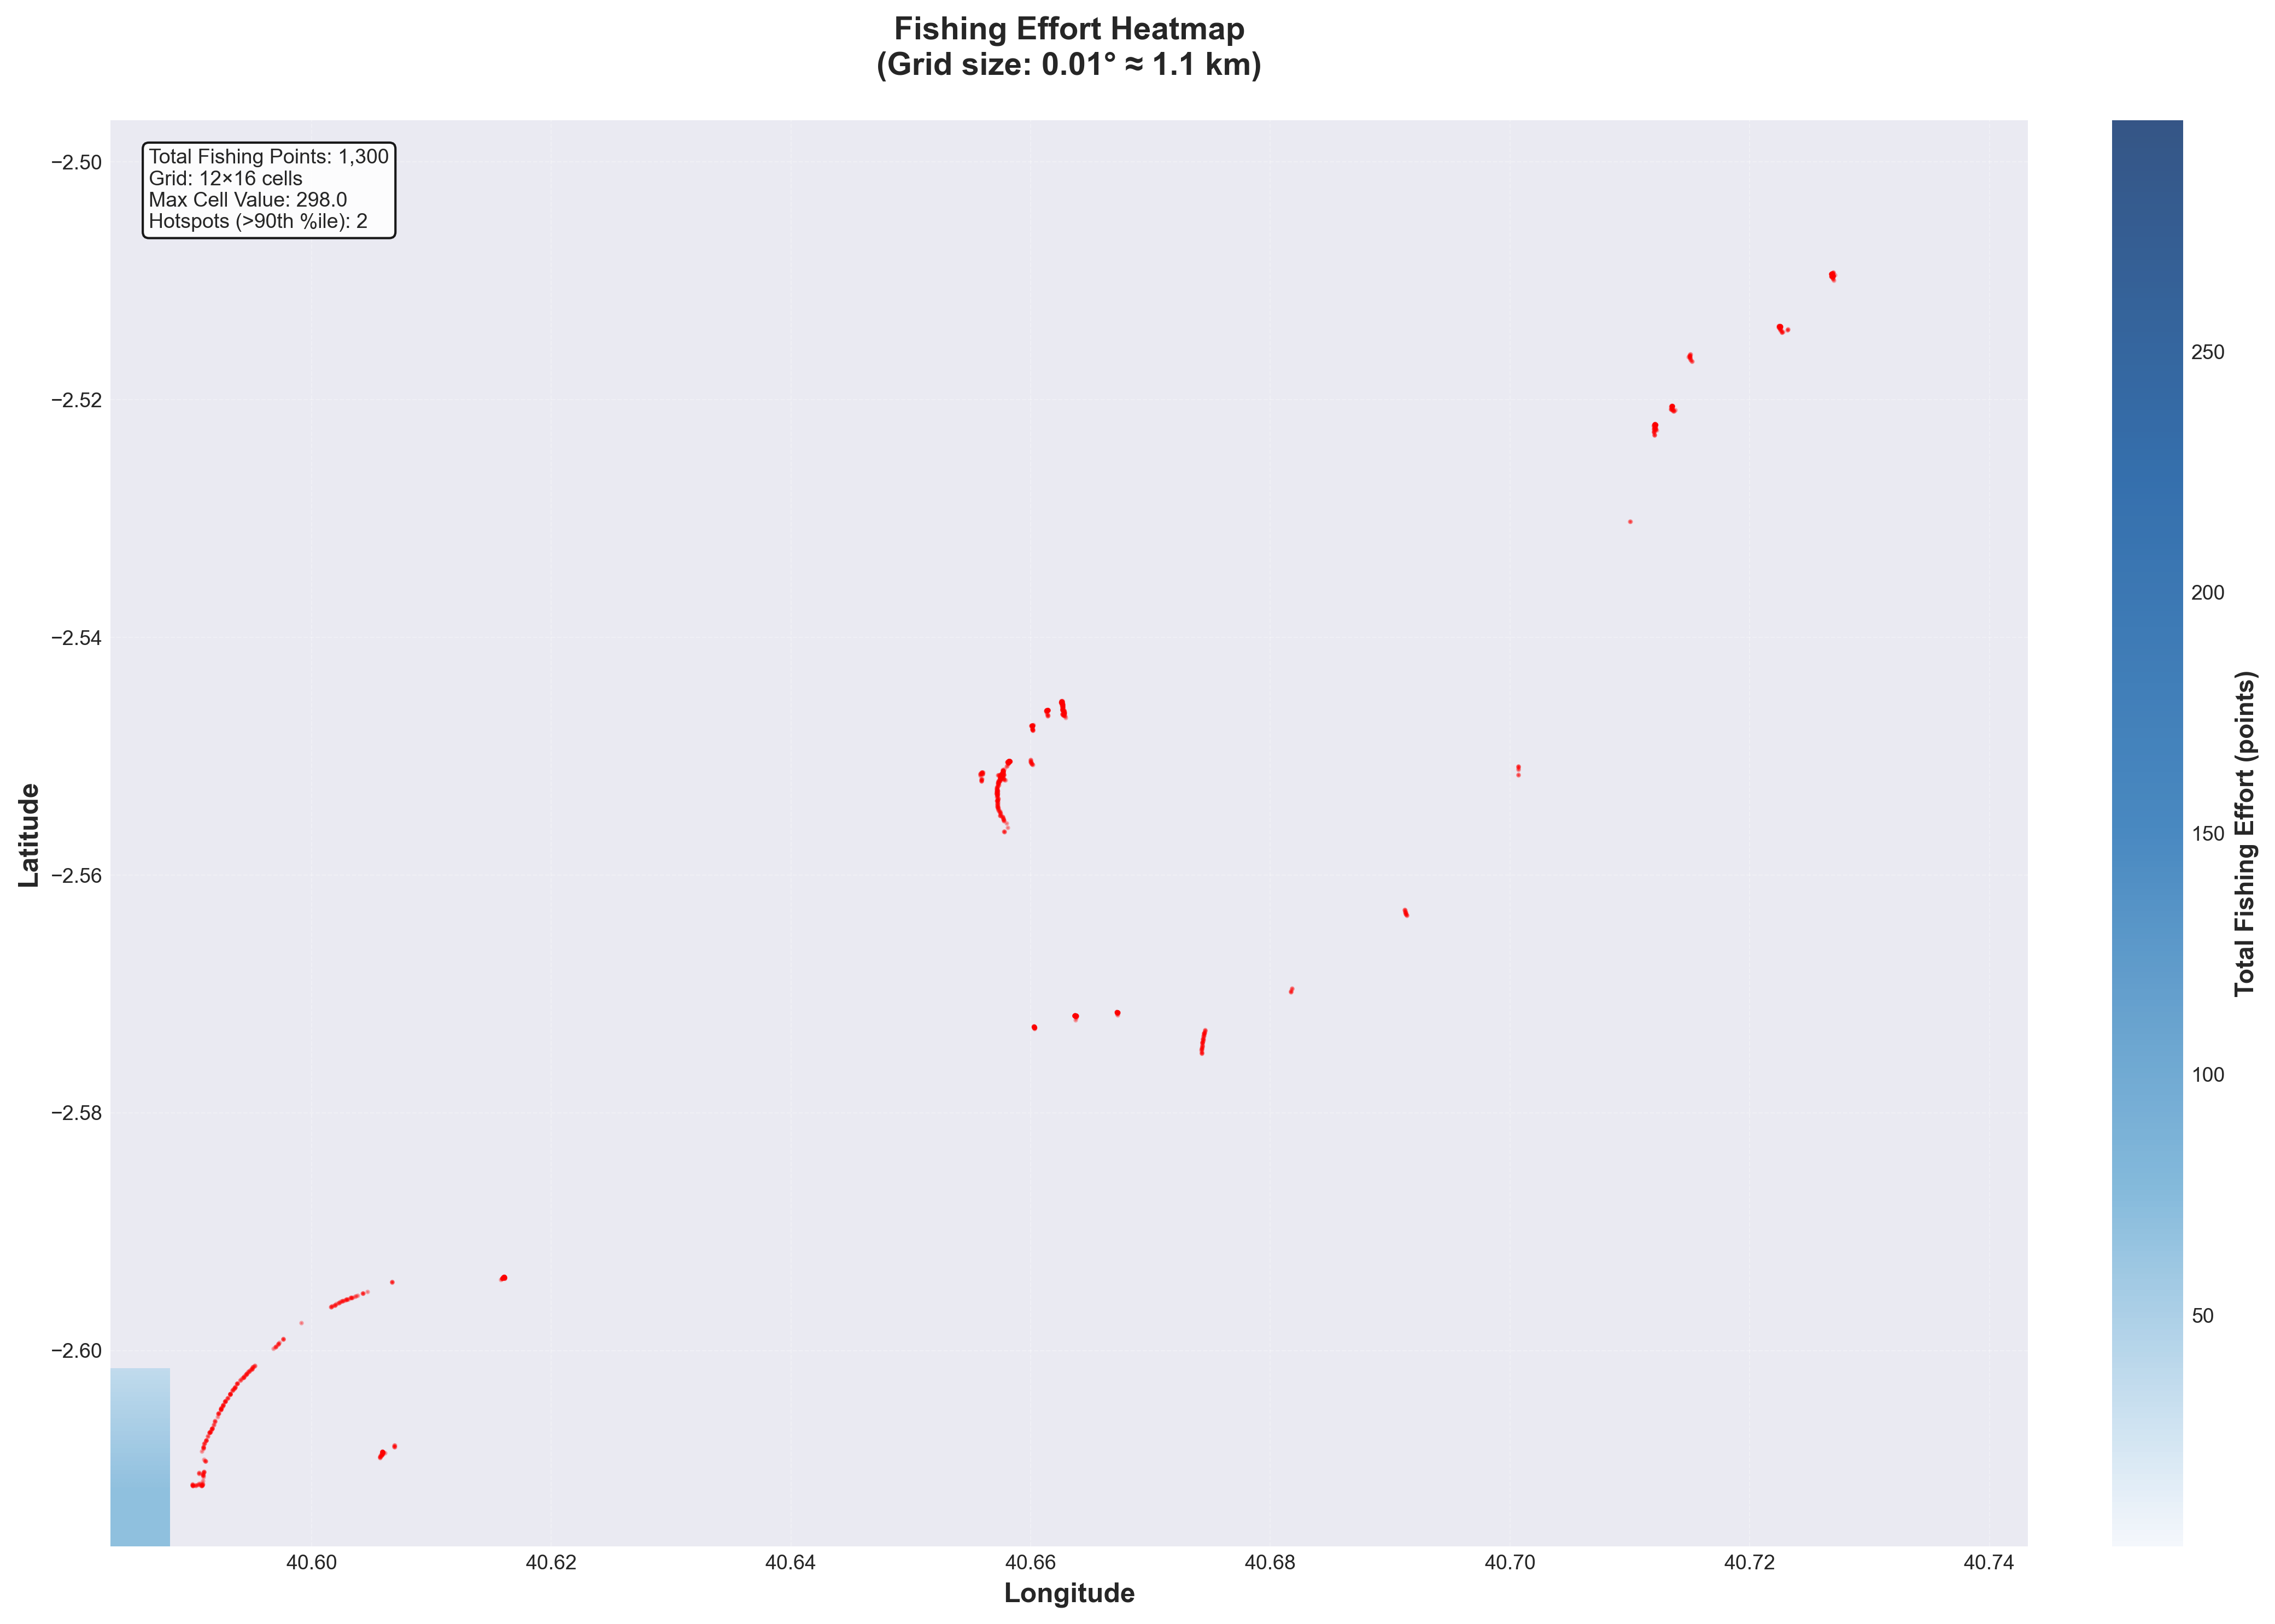


📄 report/test_effort_hotspots.png


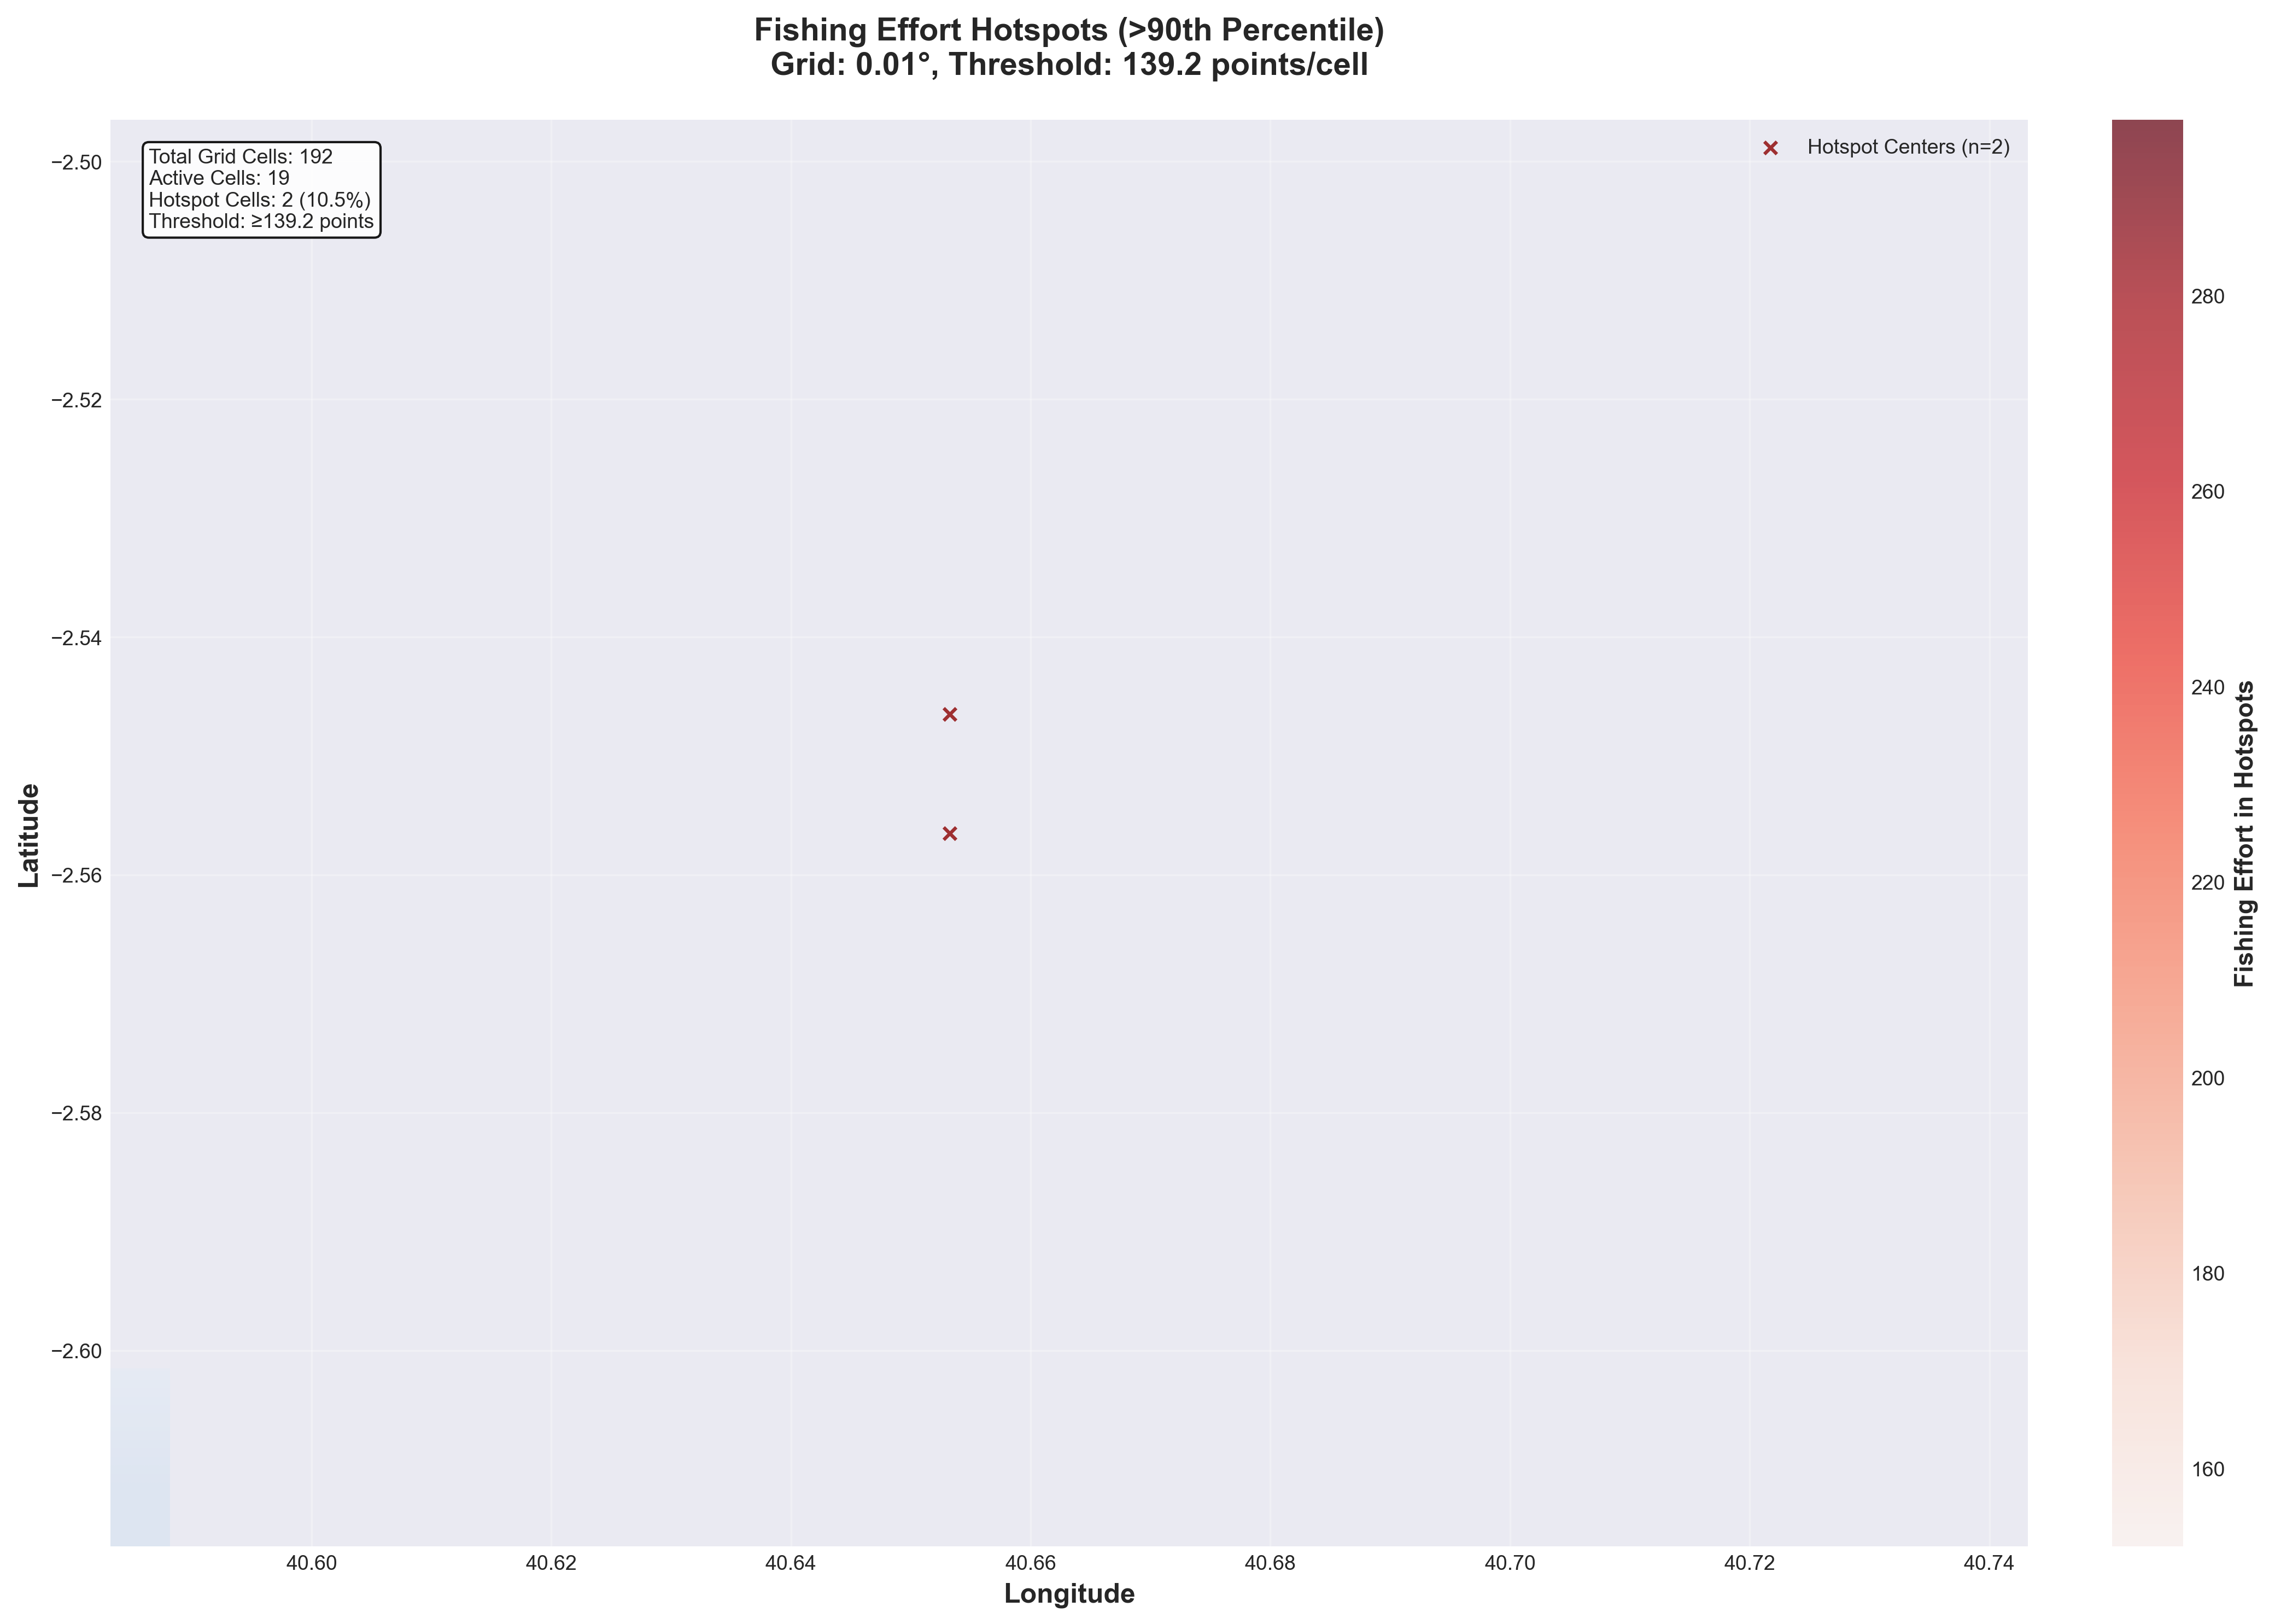


📄 report/test_effort_tracks.png


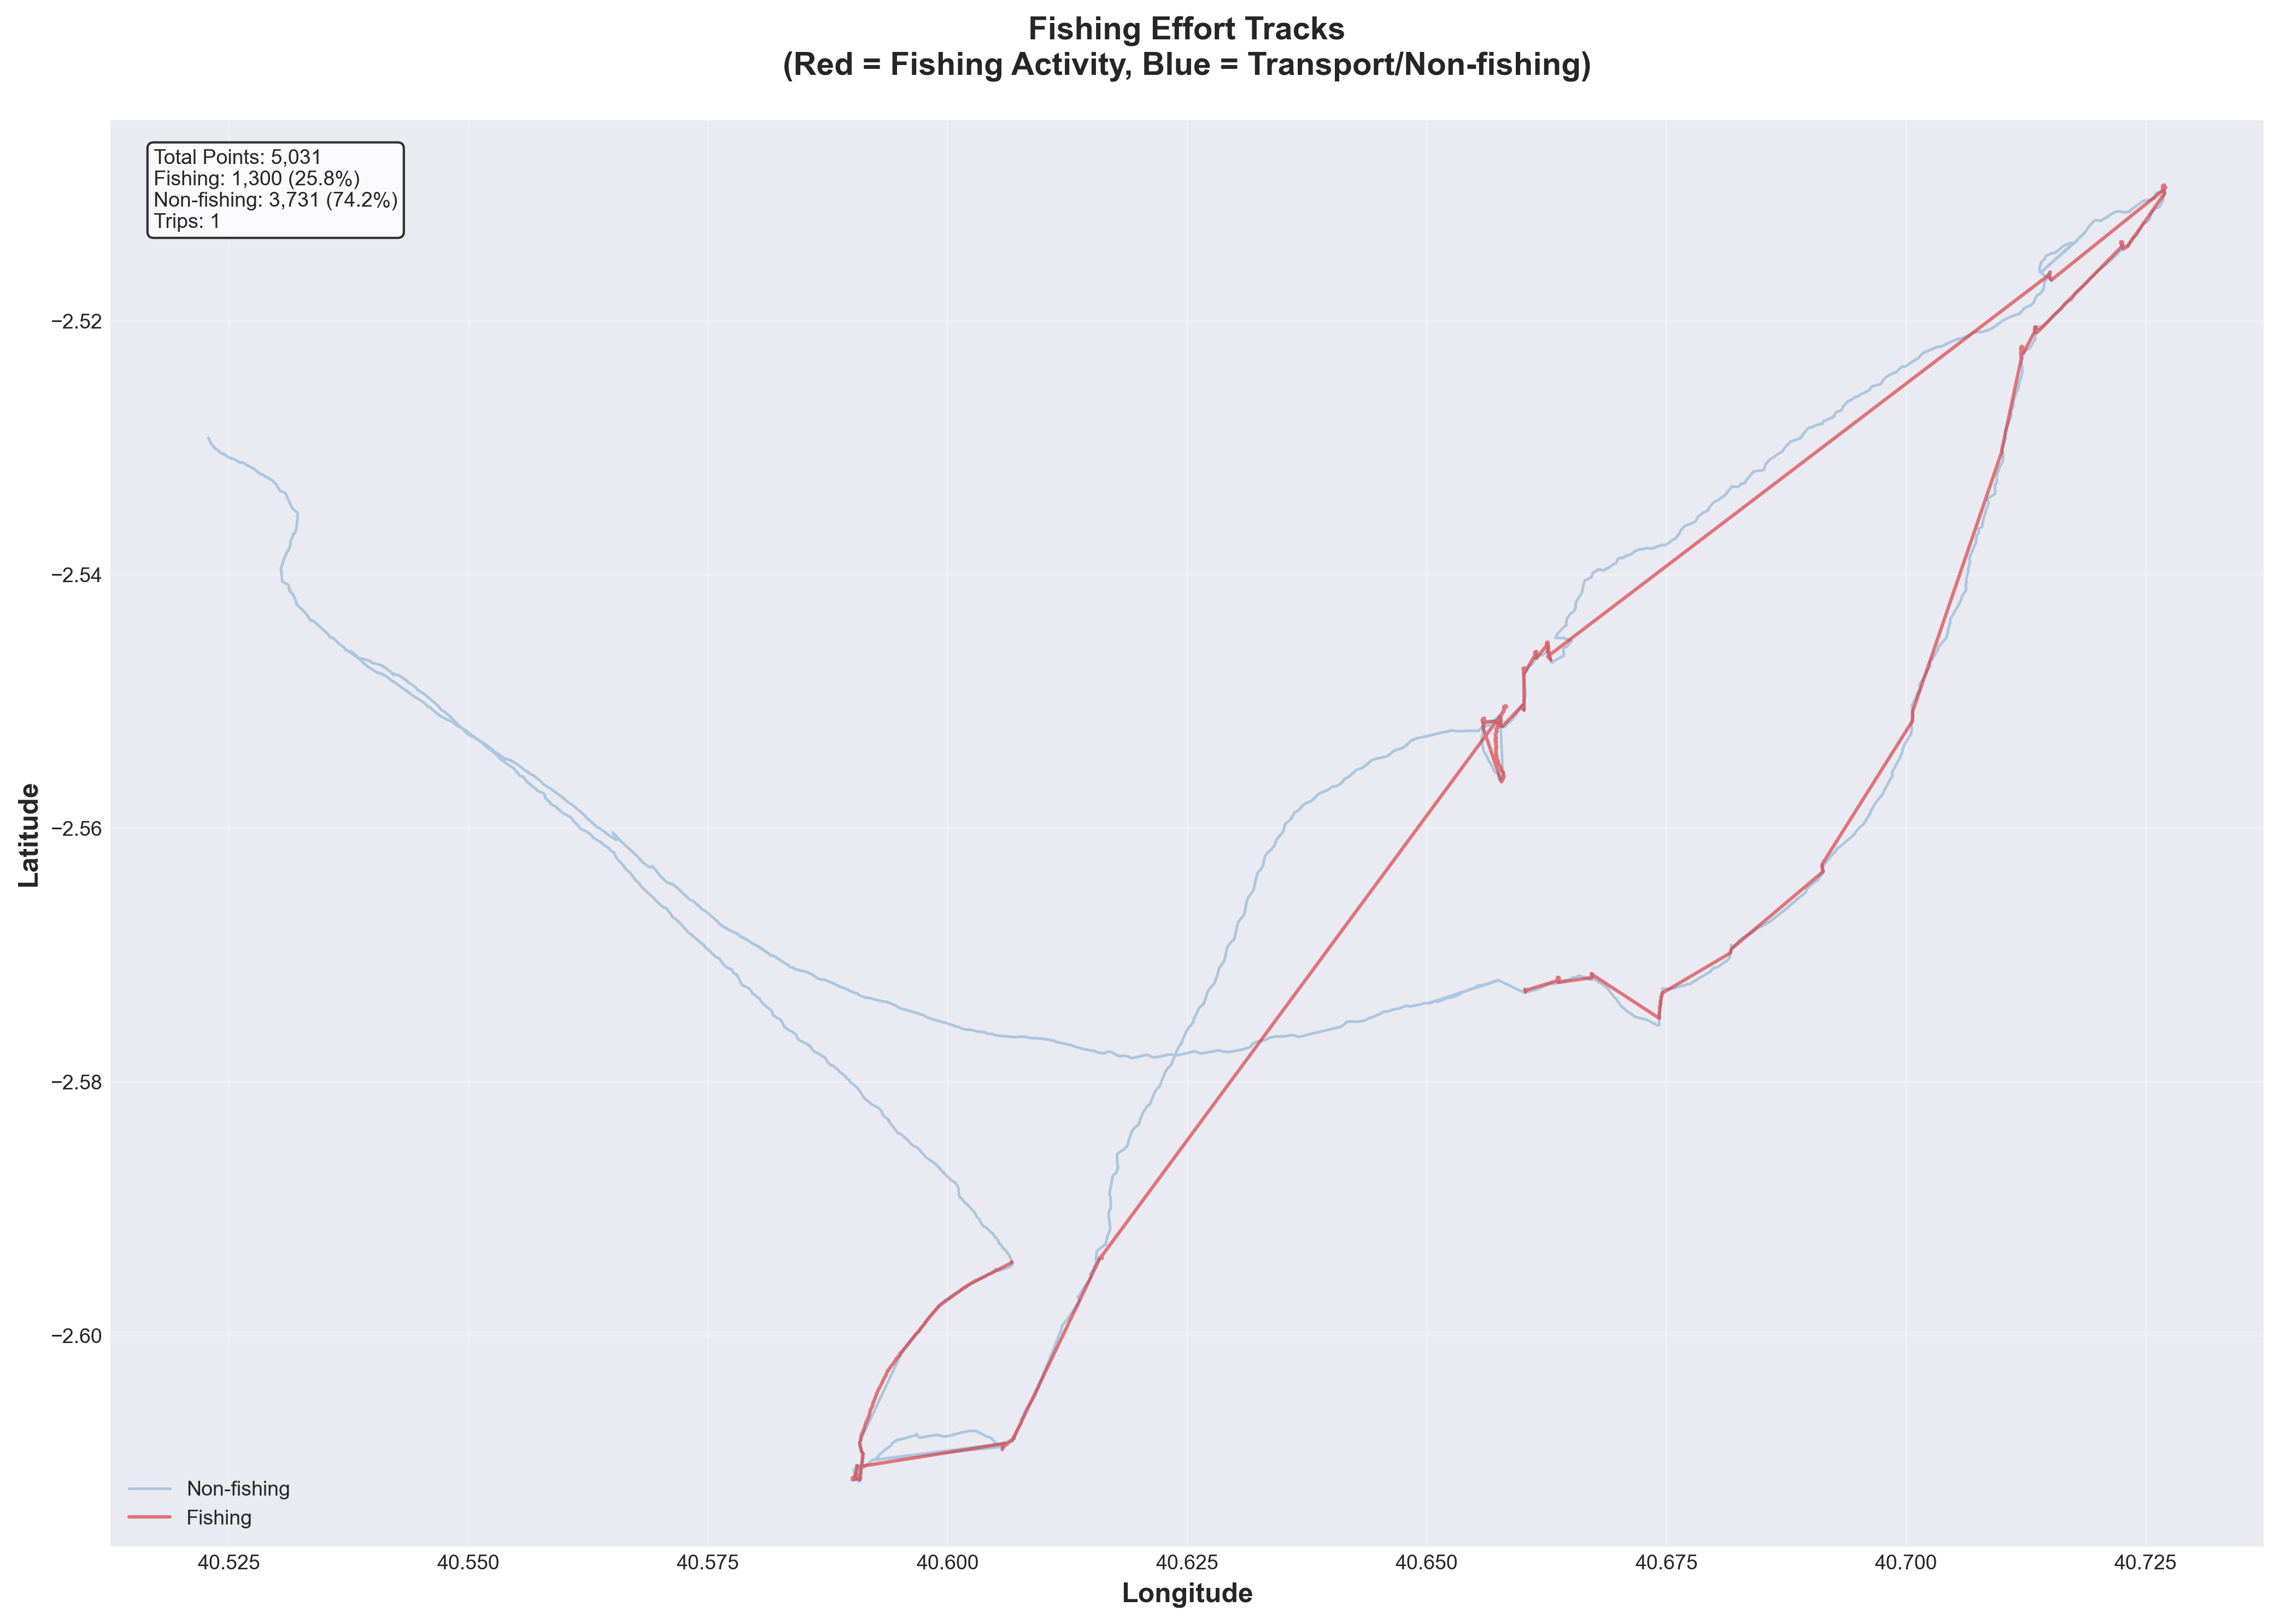


📄 test_comparison.png


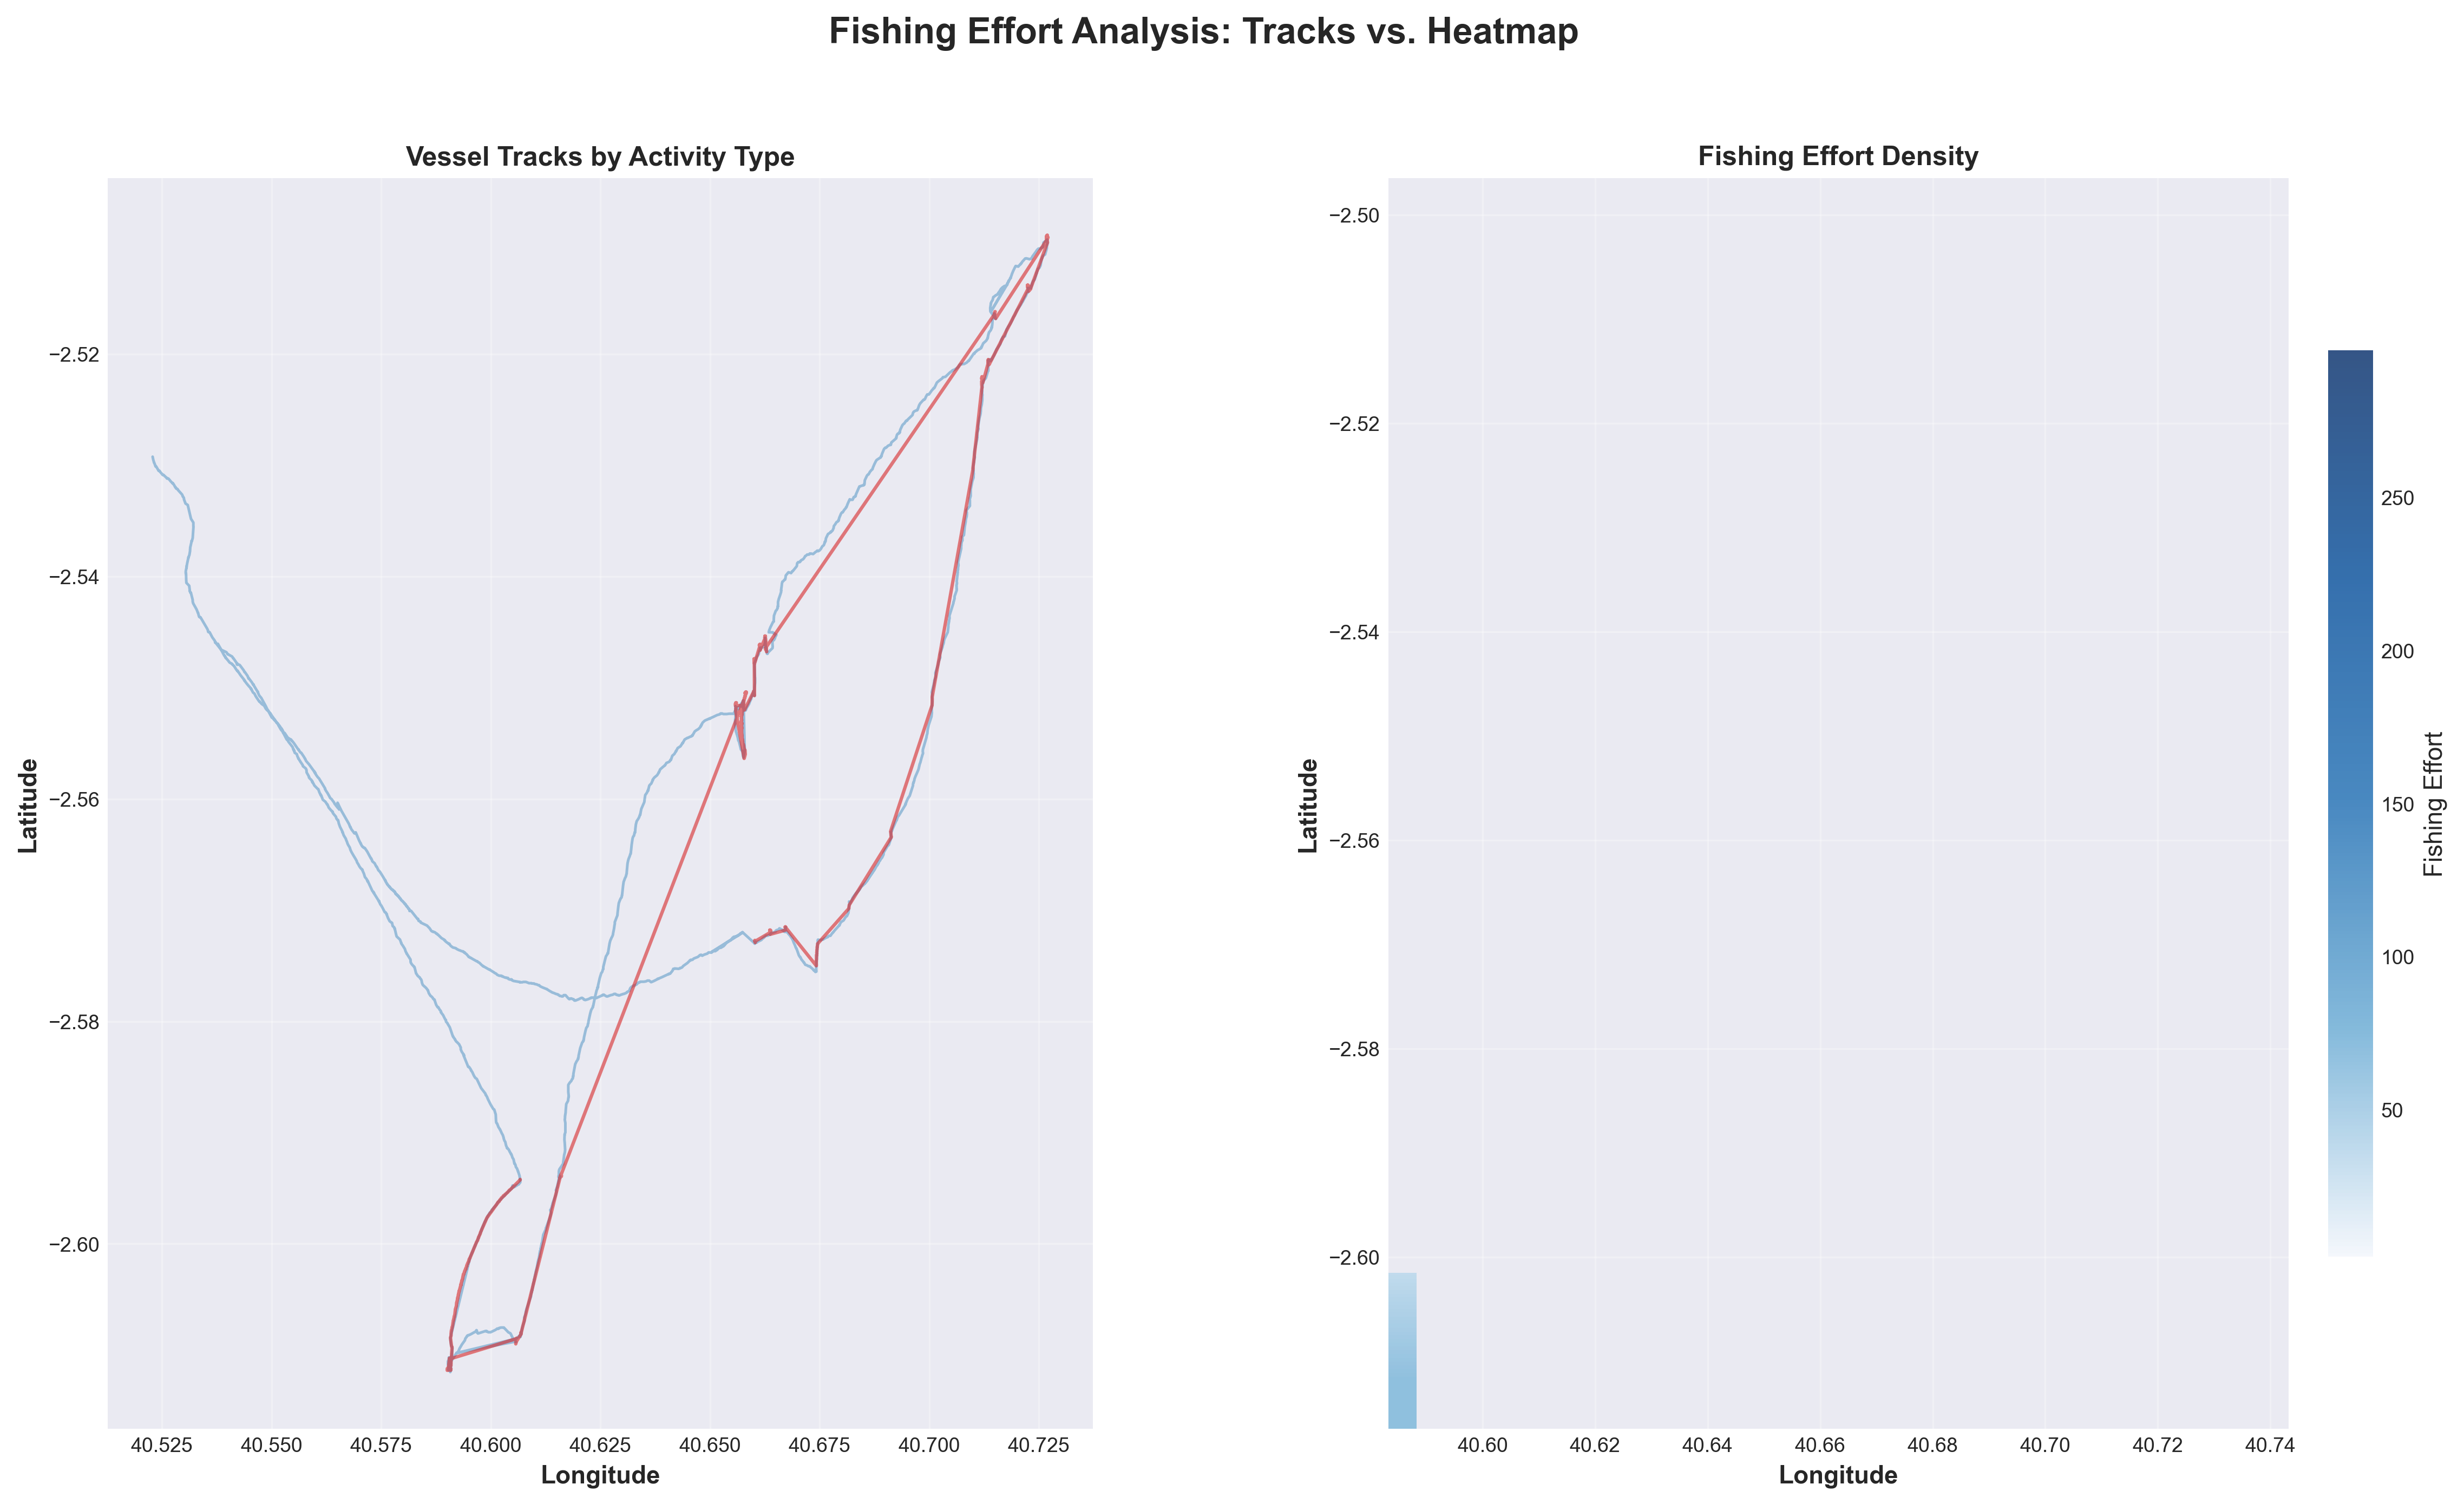


📄 test_heatmap.png


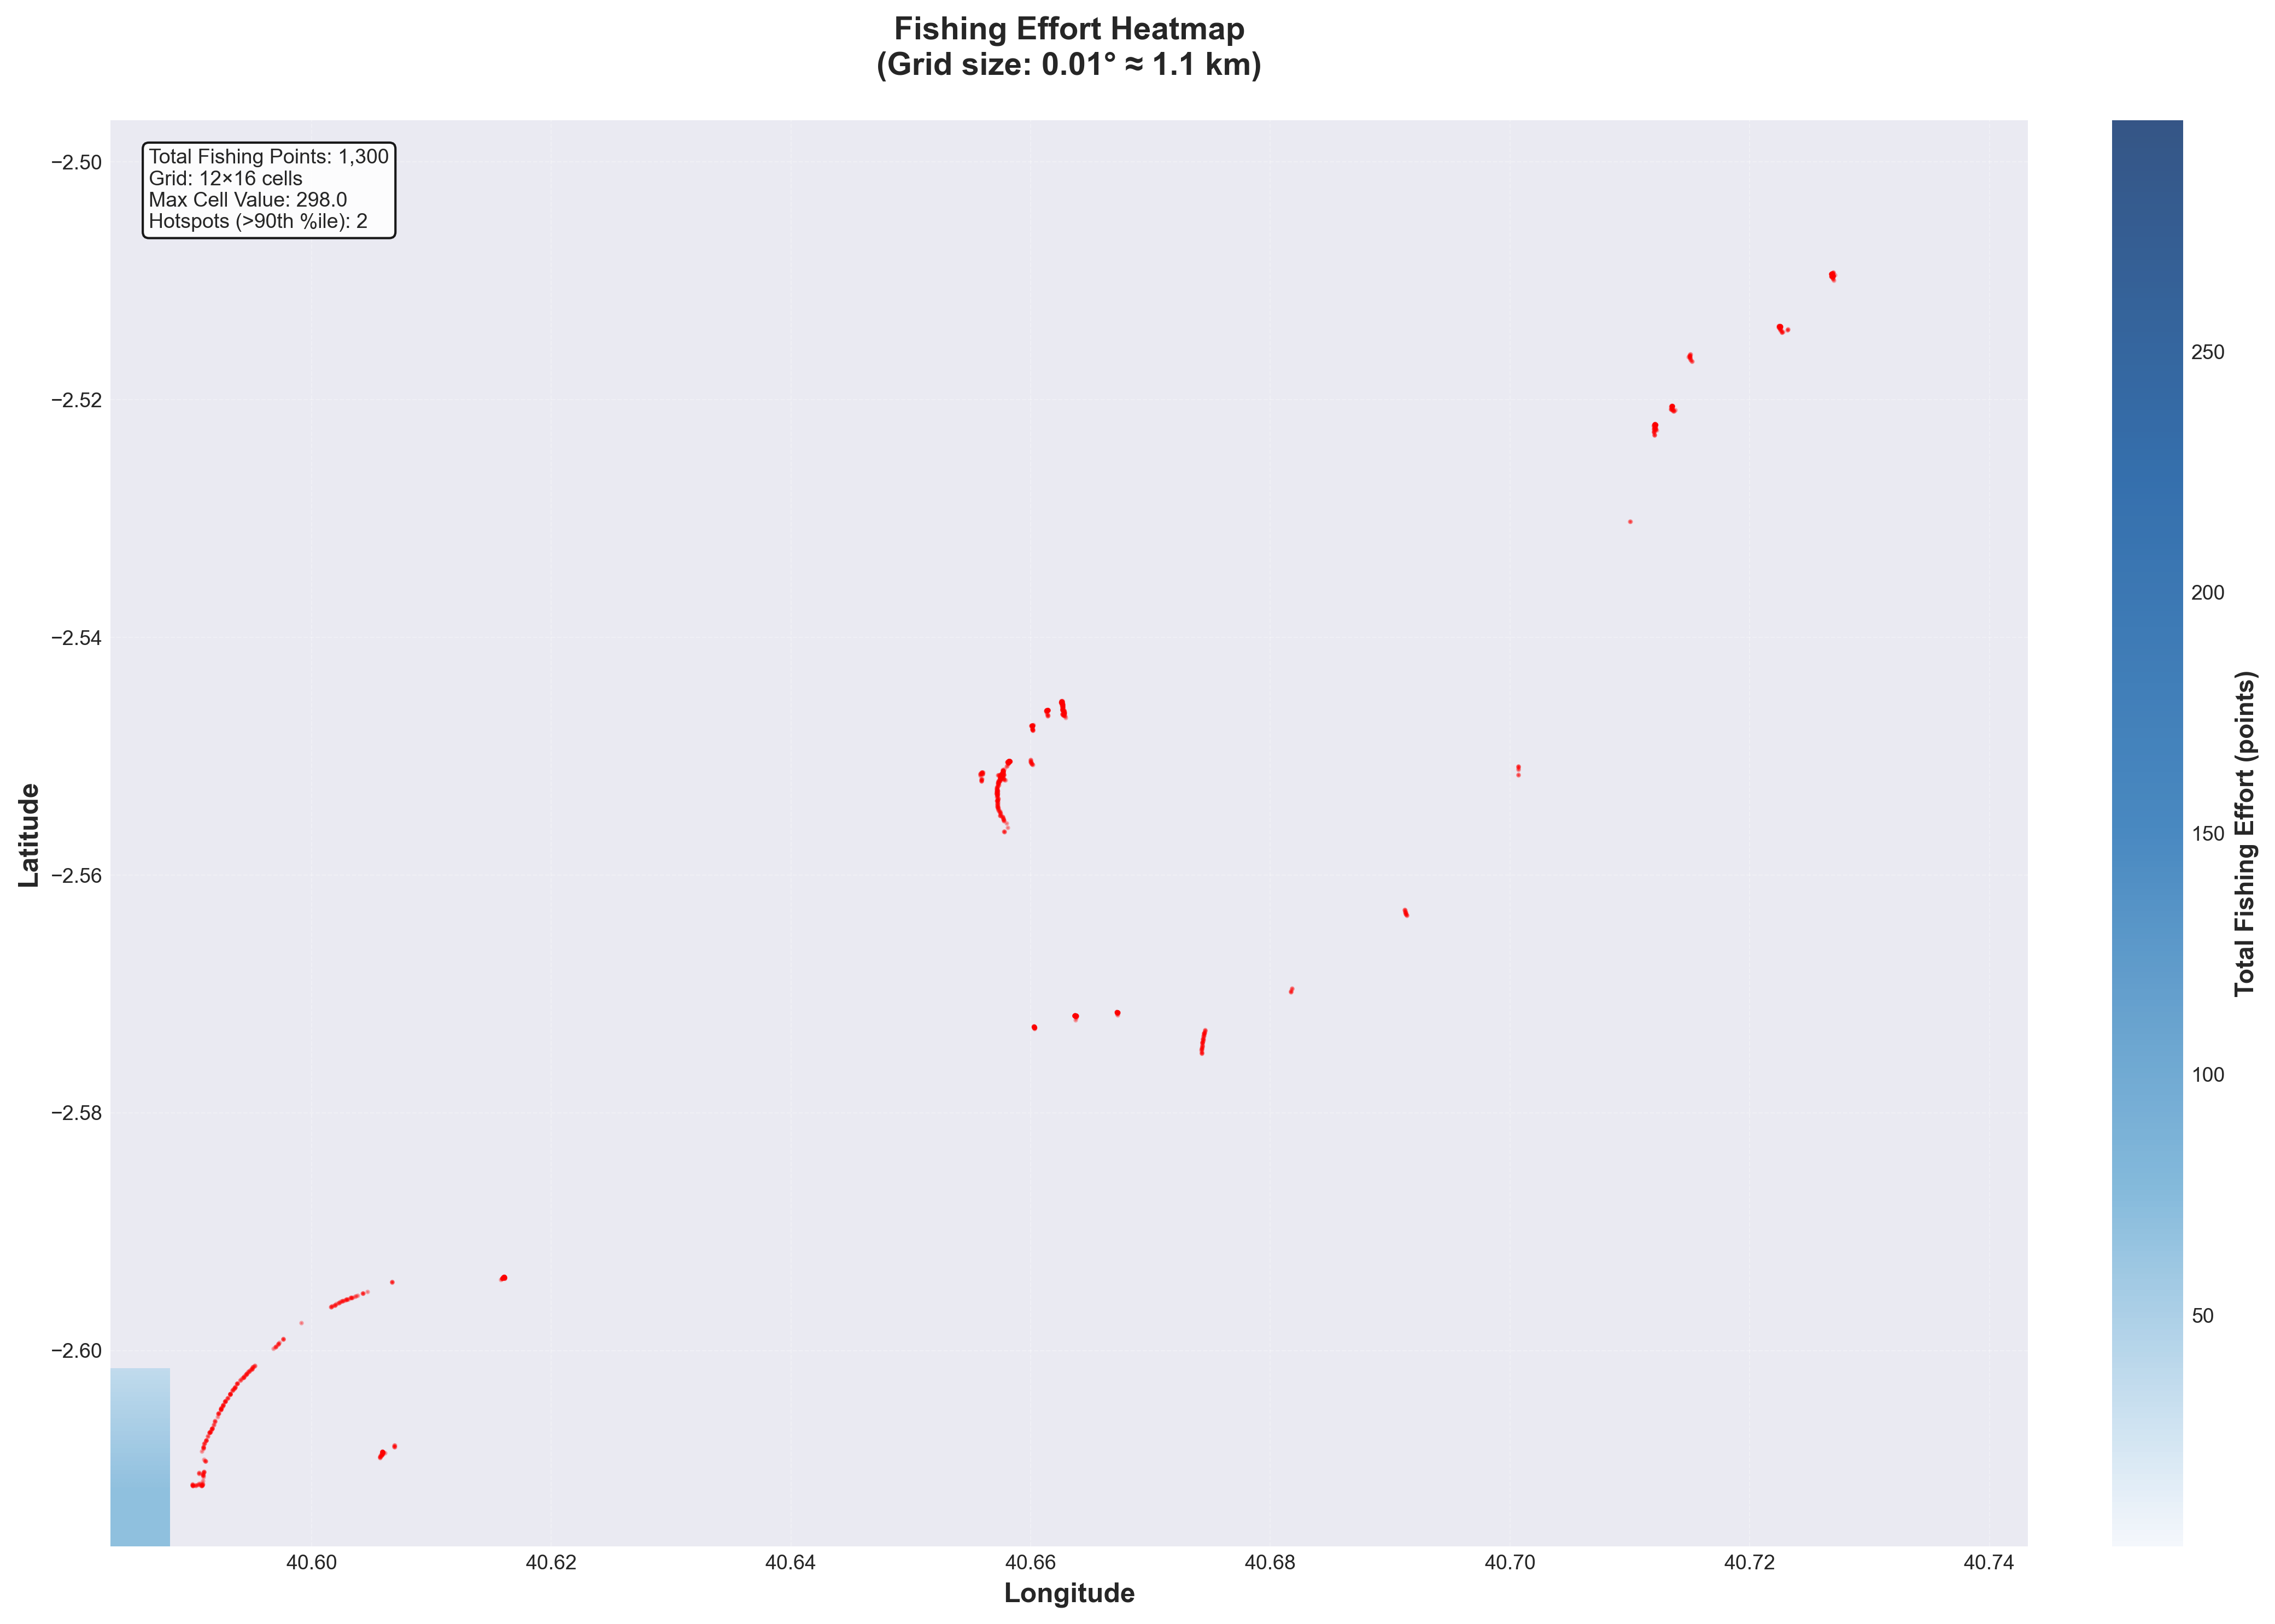


📄 test_hotspots.png


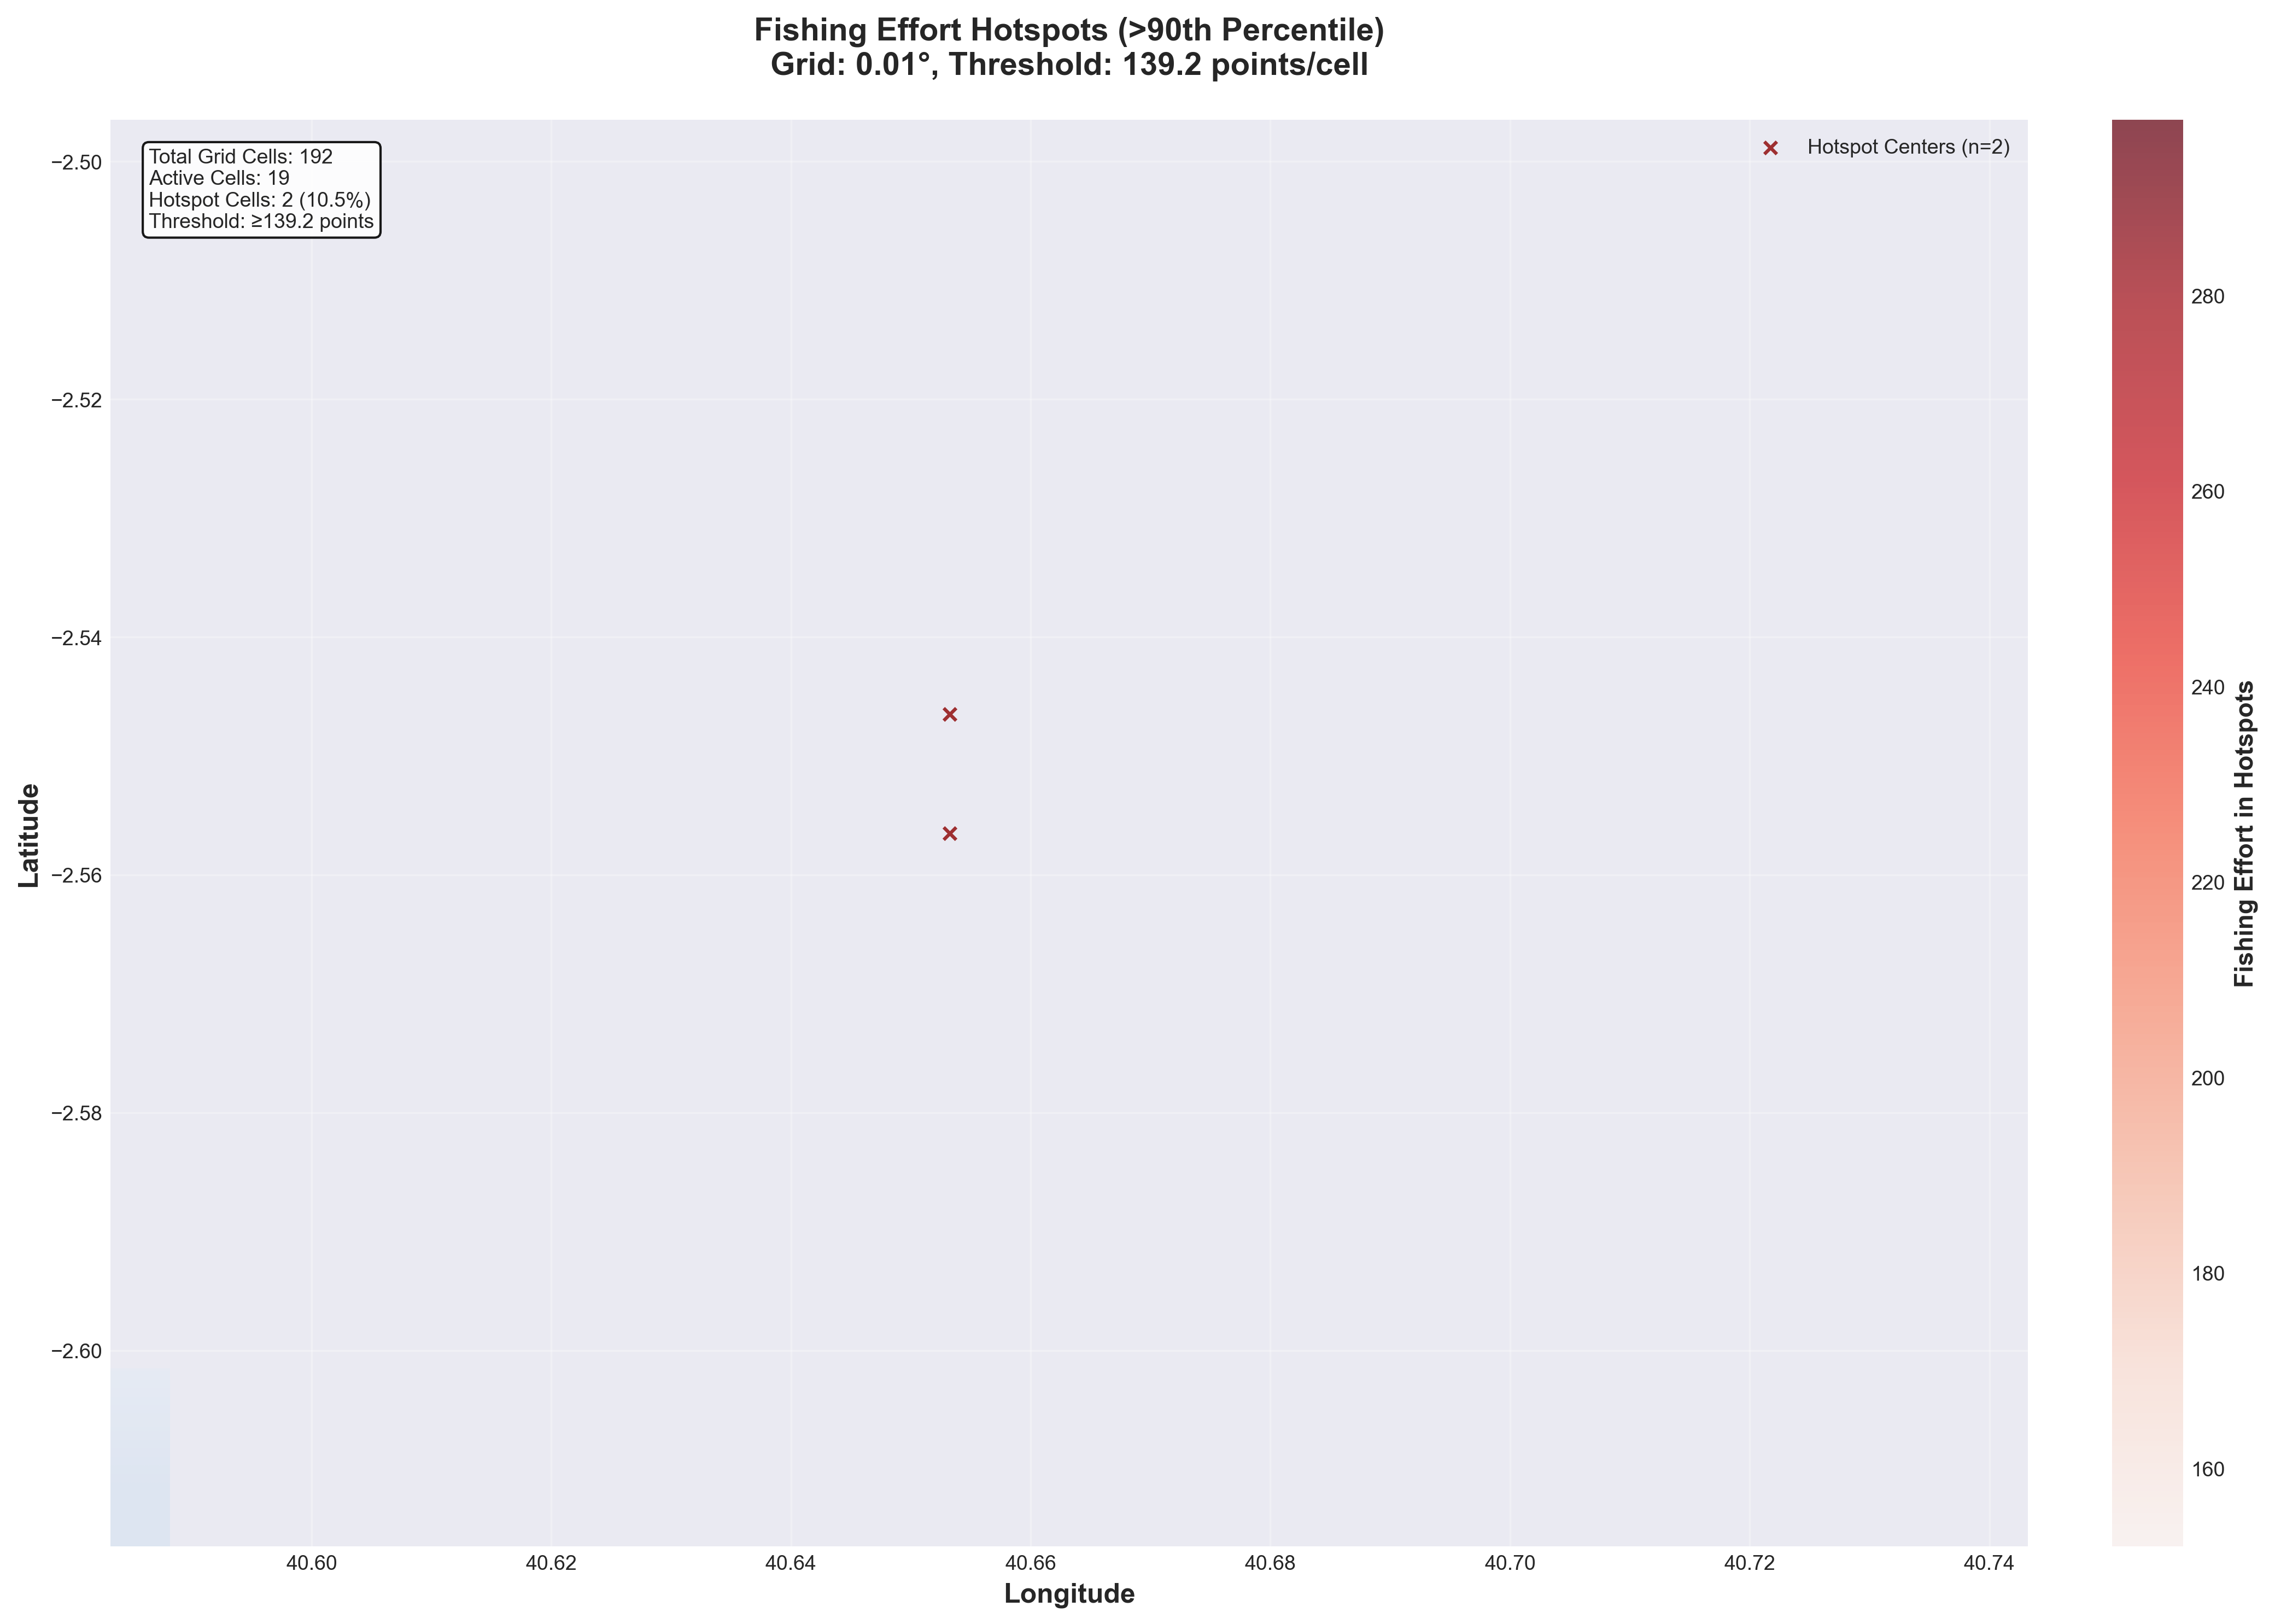


📄 test_tracks.png


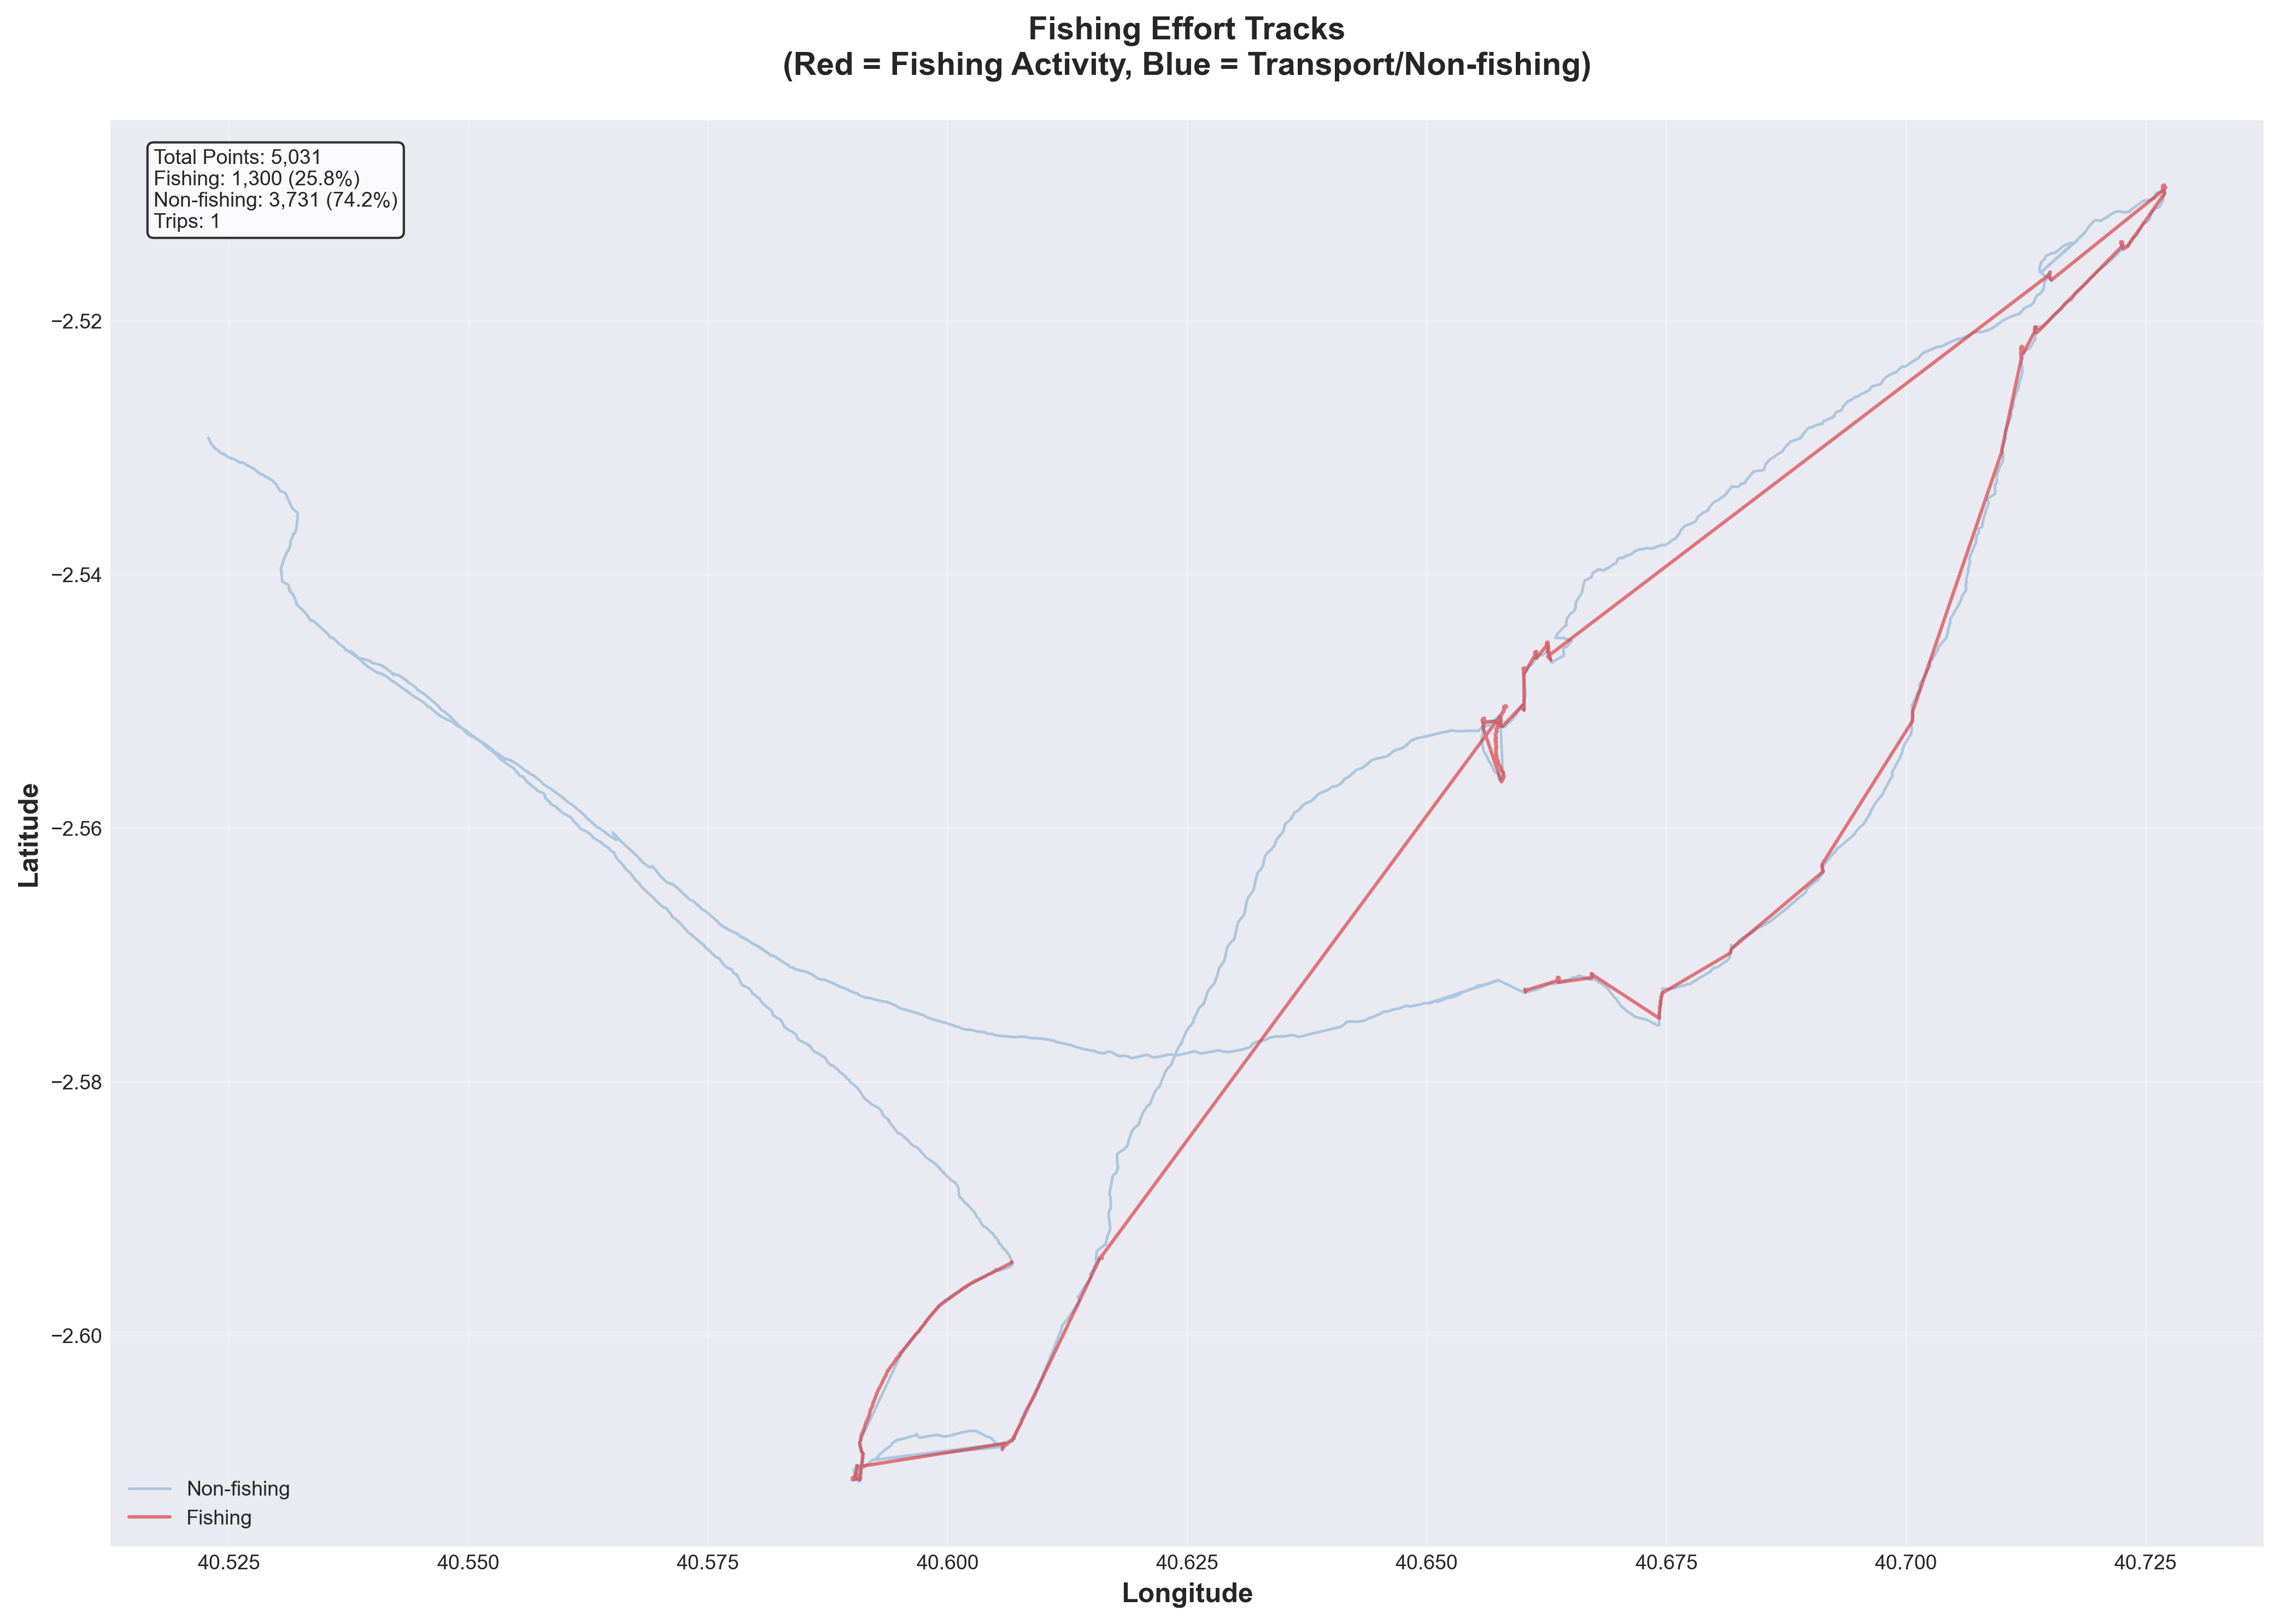

In [13]:
# Display all PNG images in output directory
image_files = sorted(output_dir.glob('**/*.png'))

print(f"📸 Displaying {len(image_files)} saved images:\n")

for img_path in image_files:
    print(f"\n{'='*70}")
    print(f"📄 {img_path.relative_to(output_dir)}")
    print(f"{'='*70}")
    display(Image(img_path, width=800))

In [5]:
import pandas as pd
from ssfaitk.utils.plot_trip_route import plot_trip_route

# Load your data
df = pd.read_parquet('../../data/kenya-pds-tracks_14119254.parquet')

# Create map
plot_trip_route(df, trip_id=14119254.0, output_path='trip.html')

# Open it
import webbrowser
webbrowser.open('trip.html')





Plotting trip 14119254.0 with 5031 points...
✓ Map saved to: trip.html
  Total points: 5031


True

In [2]:
from ssfaitk.models.effort.statistical_effort import (
    StatisticalEffortClassifier,
    predict_fishing_effort,
)

clf = StatisticalEffortClassifier()

# One-line prediction with default settings
predictions_simple = clf.predict(df)

plot_trip_route(predictions_simple, trip_id=14119254.0, output_path='trip_fishing.html')

Plotting trip 14119254.0 with 5031 points...
✓ Map saved to: trip_fishing.html
  Total points: 5031
  Fishing: 1300 (25.8%)
  Duration: 18.7 hours
  Distance: 79.5 km


PosixPath('trip_fishing.html')

In [3]:
from ssfaitk.utils.trip_file_loader import load_random_trips
# Load 10 random trips
df = load_random_trips(10, seed=42)
print(f"✓ Loaded {df['Trip'].nunique()} trips!")

✓ Loaded 10 trips!


In [16]:
from ssfaitk.utils.trip_file_loader import load_random_trips
from ssfaitk.viz.interactive_maps import create_heatmap_html

# Load sample of fleet
df = load_random_trips(1000)  # 100 random trips


from ssfaitk.models.effort.statistical_effort import (
    StatisticalEffortClassifier,
    predict_fishing_effort,
)

clf = StatisticalEffortClassifier()

# One-line prediction with default settings
predictions_simple = clf.predict(df)

# Create combined heatmap
create_heatmap_html(
    predictions_simple,
    output_path='fleet_heatmap - 10000.html',
    radius=15,
    blur=25
)

print(f"Created heatmap from {predictions_simple['trip_id'].nunique()} trips")


Found 7862 trips in /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar
Randomly selected 1000 trips (seed=None)
Selected trip IDs: ['13152719' '13610038' '13110731' '13249945' '12874953' '13382024'
 '12943004' '12938887' '12957438' '13284430']...
Loading 1000 trips...
Loading trip 13152719 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_13152719.parquet
Loaded 2,347 points for trip 13152719
  [1/1000] Trip 13152719: 2,347 points ✓
Loading trip 13610038 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_13610038.parquet
Loaded 58 points for trip 13610038
  [2/1000] Trip 13610038: 58 points ✓
Loading trip 13110731 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_13110731.parquet
Loaded 2,180 points for trip 13110731
  [3/1000] Trip 13110731: 2,180 points ✓
Loading trip 13249945 from /Users/altartur

Created heatmap from 1000 trips


In [5]:
"""from ssfaitk.utils.download_coastline import quick_setup
shapefile_path = quick_setup('zanzibar')

print(f"✓ Ready: {shapefile_path}")"""

'from ssfaitk.utils.download_coastline import quick_setup\nshapefile_path = quick_setup(\'zanzibar\')\n\nprint(f"✓ Ready: {shapefile_path}")'

In [30]:
from ssfaitk.utils.shore_distance_filter import CoastlineDistanceFilter
filter = CoastlineDistanceFilter('../../data/coastline/coastline.shp', min_distance_km=100)
predictions_simple_filtered = filter.apply_filter(predictions_simple)
create_heatmap_html(
    predictions_simple_filtered,
    output_path='fleet_heatmap - 10000 - filtered 100.html',
    radius=15,
    blur=25
)

print(f"Created heatmap from {predictions_simple_filtered['trip_id'].nunique()} trips")

Loading coastline from: ../../data/coastline/coastline.shp
✓ Coastline loaded successfully
  Extracted 4133 coastline segments


In [31]:
predictions_simple_filtered = filter.apply_filter(predictions_simple)

Harbor filter initialized with 0 reference points
  Min distance: 100 km
  Buffer zone: 0.5 km
Shore filter: 524822 points reclassified from fishing to non-fishing
  (21.37% of total points)


In [32]:
create_heatmap_html(
    predictions_simple_filtered,
    output_path='fleet_heatmap - 10000 - filtered 100.html',
    radius=15,
    blur=25
)

print(f"Created heatmap from {predictions_simple_filtered['trip_id'].nunique()} trips")

[INFO] 2025-12-07 16:03:13,577 ssfaitk.viz.interactive_maps: Saved interactive heatmap: fleet_heatmap - 10000 - filtered 100.html
Saved interactive heatmap: fleet_heatmap - 10000 - filtered 100.html


Created heatmap from 1000 trips


In [34]:
# Check the columns
print("Columns in data:")
print(predictions_simple_filtered.columns.tolist())

# Check if filtering worked
print("\nOriginal effort_pred:")
print(predictions_simple_filtered['is_fishing'].value_counts())

print("\nFiltered effort_pred_filtered:")
print(predictions_simple_filtered['is_fishing_filtered'].value_counts())

print("\nDistance to shore stats:")
print(predictions_simple_filtered['dist_to_shore_km'].describe())

print("\nNear-shore flag:")
print(predictions_simple_filtered['is_near_shore'].value_counts())

Columns in data:
['timestamp', 'Boat', 'trip_id', 'latitude', 'longitude', 'Speed (M/S)', 'Range (Meters)', 'Heading', 'Boat Name', 'Community', 'latitude_prev', 'longitude_prev', 'timestamp_prev', 'distance_km', 'dt_hours', 'speed_kmh', 'speed_prev', 'acceleration', 'accel_prev', 'jerk', 'longitude_next', 'latitude_next', 'bearing', 'bearing_prev', 'turn_angle', 'speed_kmh_mean', 'speed_kmh_std', 'speed_kmh_max', 'speed_kmh_min', 'acceleration_mean', 'acceleration_std', 'acceleration_max', 'acceleration_min', 'turn_angle_mean', 'turn_angle_std', 'turn_angle_max', 'turn_angle_min', 'speed_cv', 'accel_cv', 'dist_to_start_km', 'straightness', 'radius_gyration_km', 'sinuosity', 'hour', 'is_daytime', 'point_number', 'total_points', 'trip_position', 'is_fishing_speed', 'is_transit_speed', 'is_high_turning', 'is_low_straightness', 'is_high_sinuosity', 'is_clustered', 'is_variable_speed', 'fishing_score', 'is_fishing', 'dist_to_shore_km', 'is_near_shore', 'is_fishing_filtered']

Original effo

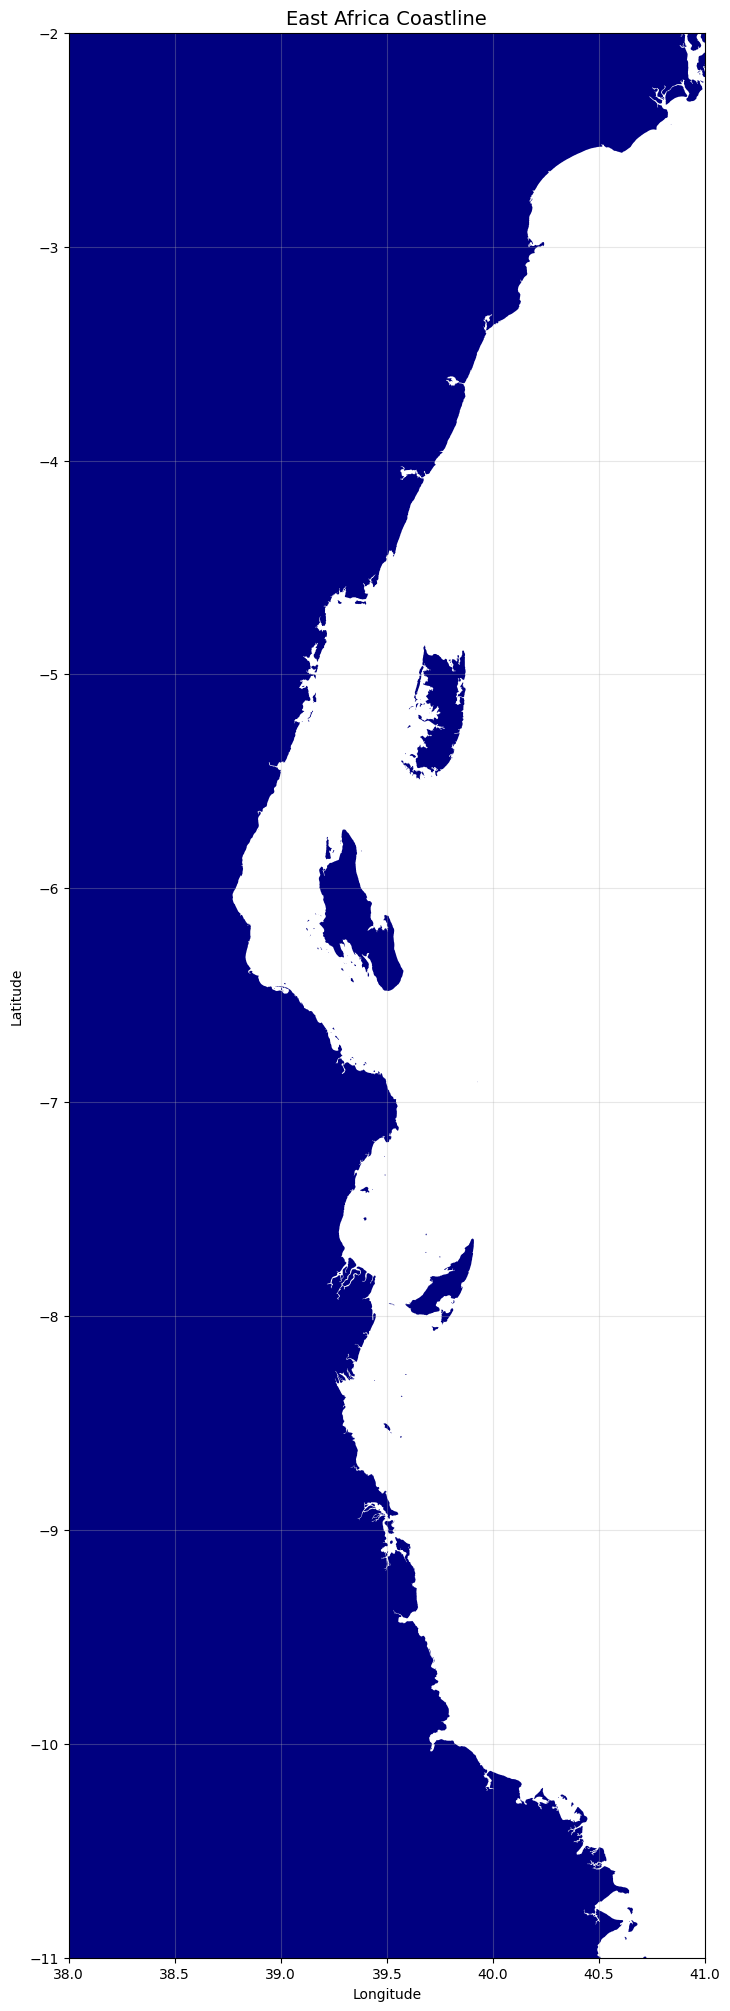

✓ Showing Kenya/Tanzania coast


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load coastline
coastline = gpd.read_file('../../data/coastline/GSHHS_f_L1.shp')

# Plot with region bounds
fig, ax = plt.subplots(figsize=(30, 25))
coastline.plot(ax=ax, color='navy', linewidth=1)

# Zoom to Kenya/Tanzania region
ax.set_xlim(38, 41)   # Longitude
ax.set_ylim(-11, -2)  # Latitude

ax.set_title('East Africa Coastline', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

print(f"✓ Showing Kenya/Tanzania coast")

---
## Summary & Next Steps

### ✅ What We Tested

1. ✓ Synthetic data generation
2. ✓ Effort classifier training
3. ✓ Predictions on track data
4. ✓ Track plot (colored routes)
5. ✓ Heatmap (spatial density)
6. ✓ Hotspot analysis
7. ✓ Comparison plot
8. ✓ Complete report generation
9. ✓ Interactive maps (if folium installed)

### 📁 Output Files

All outputs are saved to: `test_outputs/`

### 🎯 Next Steps

1. **Use with your real data:**
   ```python
   df = pd.read_csv('your_tracks.csv')
   df_pred = model.predict_df(df)
   plot_effort_heatmap(df_pred, 'your_heatmap.png')
   ```

2. **Customize visualizations:**
   - Adjust `grid_size` (0.005 to 0.05)
   - Change `percentile_threshold` for hotspots
   - Use different `aggregation` methods

3. **Generate reports:**
   ```python
   from ssfaitk.viz import generate_effort_report
   generate_effort_report(df_pred, 'outputs/my_report/')
   ```

4. **See full documentation:**
   - Quick Start: `docs/QUICK_START_VIZ.md`
   - Complete Guide: `docs/VISUALIZATION_GUIDE.md`

### 🐛 Troubleshooting

If you see errors:
- Ensure toolkit is installed: `pip install -e .[viz]`
- Check column names match (Latitude/lat/LATITUDE all work)
- For large datasets, increase `grid_size` to 0.02 or 0.05

---

**✨ All tests passed! Your visualization system is ready to use.**

In [1]:
from ssfaitk.utils.trip_file_loader import load_random_trips
from ssfaitk.viz.interactive_maps import create_heatmap_html

# Load sample of fleet
df = load_random_trips(2500)  # 100 random trips


from ssfaitk.models.effort.statistical_effort_enhanced import StatisticalEffortClassifier
from ssfaitk.models.effort.statistical_effort import StatisticalEffortClassifier as SEC


clf = SEC()

# One-line prediction with default settings
predictions_simple = clf.predict(df)

# Create combined heatmap
create_heatmap_html(
    predictions_simple,
    output_path='fleet_heatmap - 2500.html',
    radius=15,
    blur=25
)

print(f"Created heatmap from {predictions_simple['trip_id'].nunique()} trips")

Found 7862 trips in /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar
Randomly selected 2500 trips (seed=None)
Selected trip IDs: ['14064838' '13057351' '12926978' '12852787' '13610944' '12937984'
 '13179113' '12949121' '13263704' '13467200']...
Loading 2500 trips...
Loading trip 14064838 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_14064838.parquet
Loaded 5,058 points for trip 14064838
  [1/2500] Trip 14064838: 5,058 points ✓
Loading trip 13057351 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_13057351.parquet
Loaded 1,779 points for trip 13057351
  [2/2500] Trip 13057351: 1,779 points ✓
Loading trip 12926978 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_12926978.parquet
Loaded 5,918 points for trip 12926978
  [3/2500] Trip 12926978: 5,918 points ✓
Loading trip 12852787 from /Users/al

Created heatmap from 2500 trips


In [26]:
from ssfaitk.utils.plot_trip_route import plot_trip_route
randome_trip = 2012414157.0 # predictions_simple.sample(n=1)['trip_id'].iloc[0]
plot_trip_route(predictions_simple, trip_id=randome_trip, output_path=f'trip {randome_trip}.html')

ValueError: No data found for trip ID: 2012414157.0

In [23]:
predictions_simple.loc[predictions_simple['is_start_phase'] == True, 'is_fishing'] = 0
predictions_simple.loc[predictions_simple['is_end_phase'] == True, 'is_fishing'] = 0

In [24]:
plot_trip_route(predictions_simple, trip_id=randome_trip, output_path=f'trip {randome_trip}-.html')

Plotting trip 13506395.0 with 1956 points...
✓ Map saved to: trip 13506395.0-.html
  Total points: 1956
  Fishing: 458 (23.4%)
  Duration: 12.9 hours
  Distance: 23.5 km


PosixPath('trip 13506395.0-.html')

In [31]:
from ssfaitk.utils.trip_file_loader import load_trip

df = load_trip('12414157')  # 100 random trips
clf = StatisticalEffortClassifier()

# One-line prediction with default settings
predictions_simple = clf.predict(df)

Loading trip 12414157 from /Users/altarturhamza/Documents/GitHub/ssf-ai-toolkit/examples/data/pds-trips/zanzibar/pds-tracks_12414157.parquet
Loaded 3,045 points for trip 12414157
Resolved columns: lat=Lat, lon=Lng, time=Time, trip=Trip
Processing 3,045 points across 1 trips
Computing kinematic features...
Computing local statistics...
Computing spatial features...
Computing temporal features...
Applying statistical classification rules...
Detecting trip phases...
  Start zone: 1.0 km or first 5% of trip
  End zone: 1.0 km or last 5% of trip
  Starting phase: 0 points (0.0%)
  Ending phase: 633 points (20.8%)
  In progress: 2,412 points (79.2%)
Activity type distribution:
  sailing: 2,106 (69.2%)
  ending_trip: 633 (20.8%)
  fishing: 306 (10.0%)
✓ Classification complete: 19.1% classified as fishing


In [33]:
plot_trip_route(predictions_simple, trip_id=12414157, output_path=f'trip {randome_trip} -- new.html')

Plotting trip 12414157 with 3045 points...
✓ Map saved to: trip 2012414157.0 -- new.html
  Total points: 3045
  Fishing: 582 (19.1%)
  Duration: 30.0 hours
  Distance: 44.5 km


PosixPath('trip 2012414157.0 -- new.html')

In [34]:
predictions_simple.loc[predictions_simple['is_start_phase'] == True, 'is_fishing'] = 0
predictions_simple.loc[predictions_simple['is_end_phase'] == True, 'is_fishing'] = 0

In [35]:
plot_trip_route(predictions_simple, trip_id=12414157, output_path=f'trip {randome_trip} -- new --.html')

Plotting trip 12414157 with 3045 points...
✓ Map saved to: trip 2012414157.0 -- new --.html
  Total points: 3045
  Fishing: 306 (10.0%)
  Duration: 30.0 hours
  Distance: 44.5 km


PosixPath('trip 2012414157.0 -- new --.html')

In [36]:
clf = SEC()
# One-line prediction with default settings
predictions_simple_old = clf.predict(df)
plot_trip_route(predictions_simple_old, trip_id=12414157, output_path=f'trip {randome_trip}-- new -- old classifier.html')

Resolved columns: lat=Lat, lon=Lng, time=Time, trip=Trip
Processing 3045 points across 1 trips
Computing kinematic features...
Computing local statistics...
Computing spatial features...
Computing temporal features...
Applying statistical classification rules...
Classification complete: 32.3% classified as fishing


Plotting trip 12414157 with 3045 points...
✓ Map saved to: trip 2012414157.0-- new -- old classifier.html
  Total points: 3045
  Fishing: 985 (32.3%)
  Duration: 30.0 hours
  Distance: 44.5 km


PosixPath('trip 2012414157.0-- new -- old classifier.html')

In [25]:
from ssfaitk.models.effort.statistical_effort import StatisticalEffortClassifier as SEC
clf = SEC()
# One-line prediction with default settings
predictions_simple_old = clf.predict(df)
plot_trip_route(predictions_simple_old, trip_id=randome_trip, output_path=f'trip {randome_trip} old classifier.html')

Resolved columns: lat=Lat, lon=Lng, time=Time, trip=Trip
Processing 276859 points across 100 trips
Computing kinematic features...
Computing local statistics...
Computing spatial features...
Computing temporal features...
Applying statistical classification rules...
Classification complete: 20.1% classified as fishing


Plotting trip 13506395.0 with 1956 points...
✓ Map saved to: trip 13506395.0 old classifier.html
  Total points: 1956
  Fishing: 1215 (62.1%)
  Duration: 12.9 hours
  Distance: 23.5 km


PosixPath('trip 13506395.0 old classifier.html')

In [2]:
print(predictions_simple['activity_type'].value_counts())

activity_type
sailing          160005
fishing           75132
ending_trip       28717
starting_trip     13283
Name: count, dtype: int64


In [3]:
print(predictions_simple['is_fishing'].value_counts())

is_fishing
0    184687
1     92450
Name: count, dtype: int64


In [4]:
predictions_simple.columns

Index(['timestamp', 'Boat', 'trip_id', 'latitude', 'longitude', 'Speed (M/S)',
       'Range (Meters)', 'Heading', 'Boat Name', 'Community', 'latitude_prev',
       'longitude_prev', 'timestamp_prev', 'distance_km', 'dt_hours',
       'speed_kmh', 'speed_prev', 'acceleration', 'accel_prev', 'jerk',
       'longitude_next', 'latitude_next', 'bearing', 'bearing_prev',
       'turn_angle', 'speed_kmh_mean', 'speed_kmh_std', 'speed_kmh_max',
       'speed_kmh_min', 'acceleration_mean', 'acceleration_std',
       'acceleration_max', 'acceleration_min', 'turn_angle_mean',
       'turn_angle_std', 'turn_angle_max', 'turn_angle_min', 'speed_cv',
       'accel_cv', 'dist_to_start_km', 'straightness', 'radius_gyration_km',
       'sinuosity', 'hour', 'is_daytime', 'point_number', 'total_points',
       'trip_position', 'is_fishing_speed', 'is_transit_speed',
       'is_high_turning', 'is_low_straightness', 'is_high_sinuosity',
       'is_clustered', 'is_variable_speed', 'fishing_score', 'is_fish

In [2]:
from ssfaitk.utils.shore_distance_filter_updated import add_shore_filtering
df_filtered = add_shore_filtering(
    predictions_simple,
    region='zanzibar',
    method='coastline',
    coastline_shapefile='../../data/coastline/lines.shp',
    land_shapefile='../../data/coastline/GSHHS_f_L1.shp',
    min_distance_km=0.5,
    filter_land_points=True
)

print("✓ Filtering complete!")
print(f"  Near-shore removed: {df_filtered['is_near_shore'].sum():,}")
print(f"  On-land removed: {df_filtered['is_on_land'].sum():,}")

Region 'zanzibar' bbox: (-7.0, -4.5, 38.5, 40.5)
Loading: ../../data/coastline/lines.shp
⚡ Cropped: 858199 → 210 features (100.0% reduction)
✓ Coastline: 210 segments
Loading land: ../../data/coastline/GSHHS_f_L1.shp
✓ Land: 117 polygons
Filter mode: Only processing 1,234,017 fishing points (skipping 4,995,661 non-fishing)
Computing distances for 1,234,017 points...
  10,000/1,234,017 (0.8%)
  20,000/1,234,017 (1.6%)
  30,000/1,234,017 (2.4%)
  40,000/1,234,017 (3.2%)
  50,000/1,234,017 (4.1%)
  60,000/1,234,017 (4.9%)
  70,000/1,234,017 (5.7%)
  80,000/1,234,017 (6.5%)
  90,000/1,234,017 (7.3%)
  100,000/1,234,017 (8.1%)
  110,000/1,234,017 (8.9%)
  120,000/1,234,017 (9.7%)
  130,000/1,234,017 (10.5%)
  140,000/1,234,017 (11.3%)
  150,000/1,234,017 (12.2%)
  160,000/1,234,017 (13.0%)
  170,000/1,234,017 (13.8%)
  180,000/1,234,017 (14.6%)
  190,000/1,234,017 (15.4%)
  200,000/1,234,017 (16.2%)
  210,000/1,234,017 (17.0%)
  220,000/1,234,017 (17.8%)
  230,000/1,234,017 (18.6%)
  240,00

✓ Filtering complete!
  Near-shore removed: 274,086
  On-land removed: 124,031


In [6]:
df_filtered.columns

Index(['timestamp', 'Boat', 'trip_id', 'latitude', 'longitude', 'Speed (M/S)',
       'Range (Meters)', 'Heading', 'Boat Name', 'Community', 'latitude_prev',
       'longitude_prev', 'timestamp_prev', 'distance_km', 'dt_hours',
       'speed_kmh', 'speed_prev', 'acceleration', 'accel_prev', 'jerk',
       'longitude_next', 'latitude_next', 'bearing', 'bearing_prev',
       'turn_angle', 'speed_kmh_mean', 'speed_kmh_std', 'speed_kmh_max',
       'speed_kmh_min', 'acceleration_mean', 'acceleration_std',
       'acceleration_max', 'acceleration_min', 'turn_angle_mean',
       'turn_angle_std', 'turn_angle_max', 'turn_angle_min', 'speed_cv',
       'accel_cv', 'dist_to_start_km', 'straightness', 'radius_gyration_km',
       'sinuosity', 'hour', 'is_daytime', 'point_number', 'total_points',
       'trip_position', 'is_fishing_speed', 'is_transit_speed',
       'is_high_turning', 'is_low_straightness', 'is_high_sinuosity',
       'is_clustered', 'is_variable_speed', 'fishing_score', 'is_fish

In [7]:
df_filtered['is_on_land'].unique()

array([ True, False])

In [3]:
df_filtered_ = df_filtered[df_filtered['is_near_shore']!= 1]
df_filtered_ = df_filtered_[~df_filtered_['is_on_land']]

print(f"  Near-shore still: {df_filtered_['is_near_shore'].sum():,}")
print(f"  On-land still: {df_filtered_['is_on_land'].sum():,}")

  Near-shore still: 0
  On-land still: 0


In [9]:
print(f"  Is Fishing: {df_filtered_['is_fishing'].sum():,}")


  Is Fishing: 73,649


In [4]:
# Create combined heatmap
create_heatmap_html(
    df_filtered_,
    output_path='fleet_heatmap - 2500 - filtered 500m.html',
    radius=15,
    blur=25
)

[INFO] 2025-12-08 21:40:10,255 ssfaitk.viz.interactive_maps: Resolved columns: effort=is_fishing, lat=latitude, lon=longitude
Resolved columns: effort=is_fishing, lat=latitude, lon=longitude
[INFO] 2025-12-08 21:40:13,712 ssfaitk.viz.interactive_maps: Saved interactive heatmap: fleet_heatmap - 2500 - filtered 500m.html
Saved interactive heatmap: fleet_heatmap - 2500 - filtered 500m.html


PosixPath('fleet_heatmap - 2500 - filtered 500m.html')

In [ ]:
from visualize_trip_phases import visualize_trip_phases, create_multi_trip_comparison

files2 = visualize_trip_phases(
        predictions,
        trip_id=trip_id,
        output_dir='example_output/colors',
        color_by='trip_phase',
        create_charts=False
    )